In [20]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import pandas as pd
import ast
from pathlib import Path
from typing import Optional, List, Tuple, Dict, Any
from obspy.signal.filter import envelope
#from enveloc.core import XCOR
from obspy.clients.fdsn import Client
from obspy.core.util import AttribDict
import numpy as np
from obspy import Stream
import matplotlib.pyplot as plt
import os
import obspy
import shutil
from obspy import Stream
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import matplotlib.pyplot as plt
from obspy import Stream

import os, json, shutil, subprocess
from glob import glob
import numpy as np
from obspy import UTCDateTime, Inventory
import plotly.graph_objects as go

import re

import os
import shutil

import os, json, shutil, subprocess
from glob import glob
import numpy as np
from obspy import UTCDateTime, Inventory
import plotly.graph_objects as go
from obspy import Stream

In [21]:
def conv_to_datetime(df):
    new_df = []
    for i in range(len(df)):
        year = int(df[i].split('_')[0])
        month = int(df[i].split('_')[1])
        day = int(df[i].split('_')[2].split(' ')[0])
        hour = int(df[i].split('_')[2].split(' ')[1][0:2])
        minute = int(df[i].split('_')[2].split(' ')[1][2:4])
        second = int(df[i].split('_')[2].split(' ')[1][4:])
        new_df.append(obspy.UTCDateTime(year, month, day, hour, minute, second))
        
    return np.array(new_df)

In [22]:
client = Client('IRIS')
mt_rainier_cat = pd.read_csv('../src/pnw_events_esec.txt', sep = '|')

In [23]:
mt_rainier_cat['starttime'] = conv_to_datetime(mt_rainier_cat['starttime'])
mt_rainier_cat['endtime'] = conv_to_datetime(mt_rainier_cat['endtime'])

In [24]:
pd.set_option('display.max_columns', None)
mt_rainier_cat

,areaSource,areaSourceHigh,areaSourceLow,areaTotal,associationId,datlocation,depth,endtime,eventid,h,hHigh,hLow,hfall,hfall_high,hfall_low,l,lHigh,lLow,latitude,locuncertKm,longitude,lppotential,mass,massHigh,massLow,maxdistvhfKm,maxdistvhfReached,maxdisthfKm,maxdisthfReached,maxdistipKm,maxdistipReached,maxdistlpKm,maxdistlpReached,maxdistinfraKm,maxdistinfraReached,infraDetected,name,otherdataquality1to5,peakDischarge,peakDischargeLow,peakDischargeHigh,peakFlowheight,peakFlowheightLow,peakFlowheightHigh,starttime,sources,toeLat,toeLon,topLat,topLon,upstreamDrainarea,type,subtype,volume,volumeHigh,volumeLow
0,NaN,NaN,NaN,NaN,333,IRIS,NaN,2023-03-13T12:05:47.000000Z,333,700.0,1000.0,600.0,NaN,NaN,NaN,4000.0,4400.0,3600.0,46.18880,0.3,-122.16530,0,NaN,NaN,NaN,NaN,NaN,52.0,True,NaN,NaN,0.0,NaN,0.0,NaN,False,"Shoestring Notch, Mount St Helens",2,NaN,NaN,NaN,NaN,NaN,NaN,2023-03-13T11:48:08.000000Z,"Collins, E.A., Allstadt, K.E., Groult, C., Hib...",46.17540,-122.11790,46.18880,-122.16530,NaN,snow avalanche,Snow avalanches,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,120,IRIS,NaN,2011-07-06T22:25:35.000000Z,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.84300,0.2,-121.75000,0,NaN,NaN,NaN,NaN,NaN,100.0,True,NaN,NaN,0.0,NaN,NaN,NaN,NaN,Nisqually 10,4,NaN,NaN,NaN,NaN,NaN,NaN,2011-07-06T22:23:27.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",46.82050,-121.73790,46.84300,-121.75000,NaN,"rock fall, rock and ice avalanche",Rock/ice/debris avalanches and slides,71000.0,100000.0,52000.0
2,NaN,NaN,NaN,NaN,122,IRIS,NaN,1989-08-16T17:15:09.000000Z,122,2300.0,NaN,NaN,NaN,NaN,NaN,7800.0,NaN,NaN,46.87460,0.5,-121.75370,0,NaN,NaN,NaN,NaN,NaN,181.0,False,NaN,NaN,0.0,NaN,NaN,NaN,NaN,"Russell Cliff 2, Mount Rainier",3,NaN,NaN,NaN,NaN,NaN,NaN,1989-08-16T17:14:09.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",NaN,NaN,NaN,NaN,NaN,rock fall,Rock/debris falls,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,38,IRIS,NaN,2015-08-20T21:34:36.000000Z,38,1100.0,1200.0,800.0,NaN,NaN,NaN,18000.0,19000.0,7000.0,45.34630,0.5,-121.69990,0,NaN,NaN,NaN,NaN,NaN,13.0,True,NaN,NaN,0.0,NaN,NaN,NaN,NaN,"White River, Mount Hood",2,NaN,NaN,NaN,NaN,NaN,NaN,2015-08-20T20:47:12.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",45.20550,-121.60470,45.34630,-121.69990,NaN,debris flow,Lahar/debris flow/outburst flood,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,335,IRIS,NaN,2023-12-10T19:08:08.000000Z,335,1300.0,1500.0,900.0,NaN,NaN,NaN,2900.0,3200.0,2700.0,46.86120,0.0,-121.73900,0,NaN,NaN,NaN,NaN,NaN,78.0,True,NaN,NaN,0.0,NaN,9.0,True,True,"Emmons Glacier, Mount Rainier",4,NaN,NaN,NaN,NaN,NaN,NaN,2023-12-10T19:04:45.000000Z,"Collins, E.A., Allstadt, K.E., Groult, C., Hib...",46.87390,-121.70690,46.86120,-121.73900,NaN,snow avalanche,Snow avalanches,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,49000.0,61000.0,49000.0,230000.0,34,IRIS,NaN,2009-10-11T16:59:52.000000Z,34,200.0,220.0,180.0,NaN,NaN,NaN,680.0,700.0,660.0,46.81666,0.0,-120.91528,2,NaN,NaN,NaN,NaN,NaN,30.0,True,NaN,NaN,92.0,True,NaN,NaN,NaN,Nile Valley eastern failure,4,NaN,NaN,NaN,NaN,NaN,NaN,2009-10-11T16:44:27.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",46.81249,-120.92047,46.81666,-120.91528,NaN,rock slide,Rock/ice/debris avalanches and slides,960000.0,1300000.0,740000.0
73,NaN,NaN,NaN,NaN,297,IRIS,NaN,2022-09-01T20:56:27.000000Z,297,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.20490,0.4,-122.17420,0,NaN,NaN,NaN,NaN,NaN,5.0,True,NaN,NaN,0.0,NaN,NaN,NaN,False,Mount St Helens 2,1,NaN,NaN,NaN,NaN,NaN,NaN,2022-09-01T20:54:21.000000Z,"Collins, E.A., Allstadt, K.E., Groult, C., Hib...",NaN,NaN,NaN,NaN,NaN,rock fall,Rock/debris falls,NaN,NaN,NaN
74,NaN,NaN,NaN,NaN,290,IRIS,NaN,2021-09-13T17:16:54.000000Z,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.84350,0.1,-121.74780,0,NaN,NaN,NaN,NaN,NaN,18.0,True,NaN,NaN,0.0,NaN,NaN,NaN,False,"Nisqua

In [25]:
ev_lats = mt_rainier_cat['latitude']
ev_lons = mt_rainier_cat['longitude']
ev_starttimes = mt_rainier_cat['starttime']
ev_endtimes = mt_rainier_cat['endtime']
ev_types = mt_rainier_cat['type']
ev_subtypes = mt_rainier_cat['subtype']
ev_evids = mt_rainier_cat['eventid']
ev_locuncerts = mt_rainier_cat['locuncertKm']
ev_dataqualities = mt_rainier_cat['otherdataquality1to5']
ev_names = mt_rainier_cat['name']


In [27]:
# Pick the FDSN client you normally use.
# Try "IRIS" (EarthScope), or a regional one if you have it.
client = Client("IRIS")

north, east, south, west = np.max(ev_lats)+2, np.max(ev_lons)+2, np.min(ev_lats)-2, np.min(ev_lons)-2

# Infrasound/pressure channels: instrument code "D"
inv = client.get_stations(
    minlatitude=south, maxlatitude=north,
    minlongitude=west, maxlongitude=east,
    channel="*DF",   # pressure channels (e.g., BDF, HDF, LDF)
    level="channel"
)

print(inv)  # inspect what networks/stations/channels you got


Inventory created at 2026-03-05T00:30:34.357900Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?channel=%2ADF&minlat...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (10):
			1A, 8J, C0, CC, SB, TA, UO, UW, ZD, ZK
		Stations (125):
			1A.FLM1 (Top of flume)
			1A.FLM2 (Partway down flume)
			1A.FLM3 (Partway down flume)
			1A.FLM4 (Bottom of flume, attached to shed)
			1A.FLM5 (Runout pad, center of flow)
			1A.FLM6 (Runout pad, azimuthal arc)
			1A.FLM7 (Runout pad, azimuthal arc)
			1A.FLM8 (Runout pad, perpendicular to flow runout)
			1A.FLMA (Flume Crossbeam, location 1)
			1A.FLMB (Flume Crossbeam, location 2)
			1A.FLME (Flume array east)
			1A.FLMW (Flume infrasound array west)
			8J.CHIP (CHIP)
			8J.PHAB (PHAB)
			8J.RAIN (RAIN)
			C0.PALI (Palisades)
			CC.ARAT (Mount Ararat)
			CC.BRSP (Barrett Spur)
			CC.COPP (COPP)
			CC.CPCO (Central Pumice Cone, Newberry Volcano)
			CC.CRBN (Carbon R

In [28]:
def list_infrasound_channels(inv):
    rows = []
    for net in inv:
        for sta in net:
            for cha in sta:
                code = cha.code  # e.g., "BDF"
                if len(code) == 3 and code[1] == "D":
                    loc = cha.location_code or ""
                    rows.append((net.code, sta.code, loc, code, cha.latitude, cha.longitude, cha.elevation))
    return rows

infra_rows = list_infrasound_channels(inv)
print(f"Found {len(infra_rows)} infrasound channels in box.")
print(infra_rows[:5])


Found 599 infrasound channels in box.
[('1A', 'FLM1', '01', 'HDF', 44.214734, -122.254498, 467.0), ('1A', 'FLM2', '01', 'HDF', 44.214624, -122.254426, 457.9), ('1A', 'FLM3', '01', 'HDF', 44.214525, -122.254323, 450.8), ('1A', 'FLM4', '01', 'HDF', 44.214433, -122.254266, 445.6), ('1A', 'FLM5', '01', 'HDF', 44.214232, -122.254071, 444.1)]


In [31]:
def normalize_stream_by_max(st):
    """
    Normalize each trace by its absolute maximum amplitude.
    """
    st = st.copy()
    for tr in st:
        maxamp = np.max(np.abs(tr.data))
        if maxamp > 0:
            tr.data = tr.data / maxamp
    return st



def compute_snr(tr):
    """
    SNR = max(abs(tr)) / mean(abs(tr))
    """
    data = tr.data.astype(float)
    abs_data = np.abs(data)

    mean_abs = np.mean(abs_data)
    if mean_abs == 0:
        return 0

    return np.max(abs_data) / mean_abs


def drop_low_snr_traces(st, threshold=0, verbose=True):
    """
    Removes traces with SNR < threshold.

    Parameters
    ----------
    st : obspy.Stream
    threshold : float
        Minimum SNR required to keep trace.
    verbose : bool
        Print info about removed traces.

    Returns
    -------
    cleaned_stream : obspy.Stream
    """

    cleaned_stream = Stream()

    for tr in st:
        snr = compute_snr(tr)

        if snr >= threshold:
            cleaned_stream += tr
        else:
            if verbose:
                print(f"Dropping {tr.id} | SNR = {snr:.2f}")

    if verbose:
        print(f"\nKept {len(cleaned_stream)} / {len(st)} traces (threshold = {threshold})")

    return cleaned_stream
    
    
    

def preprocess_infrasound(st, inv=None, taper=0.05, freqmin= 0.5, freqmax= 5):
    """
    Simple, safe preprocessing for infrasound:
    - merge gaps
    - detrend
    - taper
    - bandpass
    Optionally remove instrument response if inventory provided.
    """
    if len(st) == 0:
        return st

    st = st.copy()
    st.merge(method=1, fill_value="interpolate")  # handle small gaps
    st.detrend("linear")
    st.detrend("demean")
    st.taper(max_percentage=taper)

    # Optional response removal (only if you have correct response metadata)
    # If you do remove_response, choose output="PA" if the response supports it.
    # if inv is not None:
    #     st.remove_response(inventory=inv, output="PA", water_level=60)
    
    for tr in st:
        df = tr.stats.sampling_rate
        nyquist = df / 2

        if freqmin <= 0:
            raise ValueError("freqmin must be > 0")

        if freqmin >= nyquist:
            print(f"Skipping {tr.id}: freqmin >= Nyquist")
            continue

        safe_freqmax = min(freqmax, nyquist * 0.99)

        tr.filter(
            "bandpass",
            freqmin=freqmin,
            freqmax=safe_freqmax,
            corners=4,
            zerophase=True
        )
        
        
    
    return st


import numpy as np
from scipy.signal import hilbert

def moving_average(x, win_samples: int):
    if win_samples <= 1:
        return x
    w = np.ones(win_samples, dtype=float) / win_samples
    return np.convolve(x, w, mode="same")

def envelope_snr(
    tr,
    smooth_sec: float = 0.5,      # envelope smoothing window
    baseline: str = "median",     # "median" or "mean"
    quantile_peak: float = 0.99,  # use robust peak instead of absolute max
    eps: float = 1e-12,
):
    """
    Robust envelope-SNR:
      peak = q-quantile of smoothed envelope (avoids single-sample spikes)
      noise = median (or mean) of smoothed envelope
      SNR = peak / noise
    """
    x = np.asarray(tr.data, dtype=float)
    if x.size == 0:
        return np.nan

    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    fs = float(tr.stats.sampling_rate)
    win = max(1, int(round(smooth_sec * fs)))

    env = np.abs(hilbert(x))
    env_s = moving_average(env, win)

    # robust "peak"
    peak = np.quantile(env_s, quantile_peak)

    if baseline == "median":
        noise = np.median(env_s)
    elif baseline == "mean":
        noise = np.mean(env_s)
    else:
        raise ValueError("baseline must be 'median' or 'mean'")

    if (not np.isfinite(noise)) or noise < eps:
        return np.nan
    return float(peak / noise)



def filter_arrays_by_envelope_snr(
    st,
    snr_threshold=4.0,
    agg="mean",          # "mean" or "median"
    **env_kwargs         # passed to envelope_snr()
):
    """
    Filters entire infrasound arrays (net, sta) whose aggregated envelope SNR
    is below snr_threshold.

    Returns:
        st_filtered
        array_snr_dict
    """

    from collections import defaultdict

    arrays = defaultdict(list)
    trace_snr_map = {}

    # --- Compute envelope SNR per trace ---
    for tr in st:
        key = (tr.stats.network, tr.stats.station)
        arrays[key].append(tr)
        trace_snr_map[tr.id] = envelope_snr(tr, **env_kwargs)

    # --- Aggregate per array ---
    array_snr = {}
    for key, trs in arrays.items():
        snrs = np.array([trace_snr_map[t.id] for t in trs], dtype=float)
        snrs = snrs[np.isfinite(snrs)]

        if snrs.size == 0:
            array_snr[key] = np.nan
        else:
            if agg == "median":
                array_snr[key] = float(np.median(snrs))
            else:
                array_snr[key] = float(np.mean(snrs))

    # --- Decide which arrays to keep ---
    keep_arrays = {
        key for key, val in array_snr.items()
        if np.isfinite(val) and val >= snr_threshold
    }

    # --- Filter stream ---
    st_filtered = Stream([
        tr for tr in st
        if (tr.stats.network, tr.stats.station) in keep_arrays
    ])

    print(f"Kept {len(keep_arrays)} arrays")
    print(f"Dropped {len(array_snr) - len(keep_arrays)} arrays")

    return st_filtered, array_snr



def plot_event_infrasound(mt_rainier_cat, event_idx, inv, client,
                          pad_before= 20, pad_after=100,
                          freqmin= 1.0, freqmax=10.0,
                          max_traces= 2e+10, snr_thresh = 1):
    """
    mt_rainier_cat: must let you access start/end as UTCDateTime or ISO string
    event_idx: index of event row
    inv: station inventory returned by get_stations (level="channel")
    """
    # ---- get start/end from your catalog row ----
    row = mt_rainier_cat.iloc[event_idx]  # if it's a pandas DF
    t0 = row["starttime"]
    t1 = row["endtime"]

    # Make sure UTCDateTime
    if not isinstance(t0, UTCDateTime):
        t0 = UTCDateTime(t0)
    if not isinstance(t1, UTCDateTime):
        t1 = UTCDateTime(t1)

    tstart = t0 - pad_before
    tend   = t1 + pad_after

    # ---- gather infrasound traces ----
    st_all = Stream()
    picked = 0

    for net in inv:
        for sta in net:
            for cha in sta:
                code = cha.code
                if len(code) == 3 and code[1] != "D":
                    continue
                loc = cha.location_code or ""

                try:
                    st = client.get_waveforms(
                        network=net.code, station=sta.code, location=loc, channel=code,
                        starttime=tstart, endtime=tend, attach_response=False
                    )
                except Exception:
                    continue

                if len(st) == 0:
                    continue

                st = preprocess_infrasound(st, inv=None, freqmin=freqmin, freqmax=freqmax)
                st_all += st
                picked += len(st)
                if picked >= max_traces:
                    break
            if picked >= max_traces:
                break
        if picked >= max_traces:
            break

    if len(st_all) == 0:
        print(f"No infrasound data found for event {event_idx} in window {tstart} - {tend}")
        return None

    # ---- plot ----
    # ObsPy's built-in plotting is quick; it makes a stacked plot per trace
    # Normalize each trace individually
    
    
    

    st_all = merge_overlaps_by_id(st_all, fill="interpolate")
    st_all = drop_exact_clones(st_all)
    st_all = drop_low_snr_traces(st_all, verbose = False)
    
    
    st_all, array_snr = filter_arrays_by_envelope_snr(
    st_all,
    snr_threshold= snr_thresh,
    agg="mean",
    smooth_sec=0.5,
    baseline="median",
    quantile_peak=0.99)
    
    st_norm = normalize_stream_by_max(st_all)

    st_norm.plot(
        type="normal",
        size=(1200, 800),
        title=f"Event {event_idx}: {t0} to {t1} "
              f"(normalized, bandpass {freqmin}-{freqmax} Hz)"
    )

    return st_all


In [51]:
def merge_overlaps_by_id(st, fill="interpolate"):
    out = Stream()
    for tr_id in sorted({tr.id for tr in st}):
        s = st.select(id=tr_id).copy()
        s.sort(keys=["starttime"])
        # This merges overlaps/gaps into as few traces as possible
        s.merge(method=1, fill_value=fill)  # method=1 is “interpolate small gaps”
        out += s
    return out




def drop_exact_clones(st: Stream) -> Stream:
    """
    Drop exact duplicate traces by id + start/end + npts.
    Uses only primitive types in the key to avoid hashing issues.
    """
    seen = set()
    out = Stream()

    for tr in st:
        # Convert UTCDateTime -> nanoseconds integer (safe + hashable)
        s_ns = int(tr.stats.starttime.ns)
        e_ns = int(tr.stats.endtime.ns)

        key = (str(tr.id), s_ns, e_ns, int(tr.stats.npts))

        if key not in seen:
            out += tr
            seen.add(key)

    return out



from collections import defaultdict

def group_by_array(st):
    arrays = defaultdict(Stream)
    for tr in st:
        net, sta, loc, cha = tr.id.split(".")
        arrays[(net, sta)] += tr
    return arrays


from obspy.core.util import AttribDict

def attach_coordinates_from_inventory(st, inv):
    """
    Attach per-trace coordinates using a channel-level Inventory.
    """
    for tr in st:
        net = tr.stats.network
        sta = tr.stats.station
        loc = tr.stats.location or ""
        cha = tr.stats.channel

        sel = inv.select(network=net, station=sta, location=loc, channel=cha)
        if len(sel.networks) == 0 or len(sel.networks[0].stations) == 0 or len(sel.networks[0].stations[0].channels) == 0:
            # no match
            continue

        ch = sel.networks[0].stations[0].channels[0]
        tr.stats.coordinates = AttribDict({
            "latitude": float(ch.latitude),
            "longitude": float(ch.longitude),
            "elevation": float(ch.elevation),
        })
    return st



from obspy.core.util import AttribDict

def attach_coordinates_from_inventory(st, inv, strict=True):
    missing = []
    for tr in st:
        net = tr.stats.network
        sta = tr.stats.station
        loc = tr.stats.location or ""
        cha = tr.stats.channel

        sel = inv.select(network=net, station=sta, location=loc, channel=cha)
        ok = (len(sel.networks) and len(sel.networks[0].stations) and len(sel.networks[0].stations[0].channels))
        if not ok:
            missing.append(tr.id)
            if strict:
                continue  # collect all missing first
            else:
                continue

        ch = sel.networks[0].stations[0].channels[0]
        tr.stats.coordinates = AttribDict(
            latitude=float(ch.latitude),
            longitude=float(ch.longitude),
            elevation=float(ch.elevation),
        )

    if strict and missing:
        raise ValueError(f"Missing channel metadata for {len(missing)} traces. Examples: {missing[:20]}")

    return st



import os
from obspy.io.sac import SACTrace

def write_array_to_sac(st_array, outdir):
    os.makedirs(outdir, exist_ok=True)
    for tr in st_array:
        c = tr.stats.coordinates
        sac = SACTrace.from_obspy_trace(tr)
        sac.stla = float(c.latitude)
        sac.stlo = float(c.longitude)
        sac.stel = float(c.elevation)
        fn = f"{tr.id.replace('.', '_')}.SAC"
        sac.write(os.path.join(outdir, fn))




def run_infrapy_pipeline_for_event(
    st_all,
    client,
    event_id,
    truth_lat=None,
    truth_lon=None,
    inv_hint=None,           # optional, if you already have some inventory
    INFRAPY="/home/ak287/miniconda3/envs/infrapy_env/bin/infrapy",
    OUTROOT="infrapy_runs",
    fk_args=None,            # NEW
    fd_args=None,            # NEW
    assoc_args=None,
    loc_args=None,
    tm_pad_sec=600,
    heat_radius=40,
    renderer="iframe",
    verbose_cli=False,     # if True, print full stdout/stderr
    print_summary=True,    # print one-line status per step/array
):
    """
    Runs: clean stream -> attach coords -> group arrays -> write SAC
          -> run_fk -> run_fd -> run_assoc -> run_loc -> plot

    Returns a dict with outputs + MAP lat/lon (if produced).
    """

    # ---------- defaults ----------
    if fk_args is None:
        fk_args = dict(
            freq_min="0.5",
            freq_max="5.0",
            back_az_min="-180.0",
            back_az_max="180.0",
            back_az_step="2.0",
            trace_vel_min="300.0",
            trace_vel_max="600.0",
            trace_vel_step="2.5",
            method="bartlett",
            signal_start=None,
            signal_end=None,
            window_len="5.0",
            sub_window_len=None,
            window_step="2.0",
        )

    if fd_args is None:
        fd_args = dict(
            window_len="3600.0",
            p_value="0.01",
            min_duration="10.0",
            back_az_width="15.0",
            fixed_thresh=None,
            thresh_ceil=None,
            return_thresh=False,
            merge_dets=False,
        )

    if assoc_args is None:
        assoc_args = dict(
            back_az_width="20",
            range_max="10",
            distance_matrix_max="12",
            cluster_threshold="7",
            trimming_threshold="5.0",
            event_population_min="3",
            event_station_min="3",
            cpu_cnt="4",
        )

    if loc_args is None:
        loc_args = dict(
            back_az_width="20",
            range_max="10",
            grid_resol="80",
            tm_resol="5",
            det_tm_stdev="10",
            cpu_cnt="4",
        )

    # ---------- event-specific directories ----------
    ev_dir = os.path.join(OUTROOT, f"ev_{event_id:04d}")
    
    # Remove existing directory (if it exists)
    if os.path.exists(ev_dir):
        shutil.rmtree(ev_dir)

    # Recreate directory
    os.makedirs(ev_dir, exist_ok=True)    
    
    
    
    fk_dir = os.path.join(ev_dir, "fk_inputs")
    det_dir = os.path.join(ev_dir, "det_all")
    event_dir = os.path.join(ev_dir, "events")
    loc_dir = os.path.join(ev_dir, "loc")
    fig_dir = os.path.join(ev_dir, "figures")

    for d in [fk_dir, det_dir, event_dir, loc_dir, fig_dir]:
        os.makedirs(d, exist_ok=True)

    EVENTSET_LABEL = os.path.join(event_dir, "my_eventset")
    LOC_LABEL = os.path.join(loc_dir, "my_eventset-ev0")

    # ---------- helpers ----------
    def run_cmd(cmd, name="", check=False):
        print("\n>", " ".join(cmd))
        res = subprocess.run(cmd, capture_output=True, text=True)
        if res.stdout.strip():
            print(f"\n[{name} STDOUT]\n{res.stdout}")
        if res.stderr.strip():
            print(f"\n[{name} STDERR]\n{res.stderr}")
        if check and res.returncode != 0:
            raise RuntimeError(f"{name} failed with code {res.returncode}")
        return res
    
    
    def run_cmd(cmd, name="", check=False, verbose=False):
        """
        Run a command quietly by default.
        - If verbose=False: only print one-line status + errors (short).
        - If verbose=True: print full stdout/stderr.
        """
        res = subprocess.run(cmd, capture_output=True, text=True)

        ok = (res.returncode == 0)

        if print_summary:
            print(f"[{name}] {'OK' if ok else 'FAIL'}")

        if (not ok) or verbose:
            # On failure, show useful info even if verbose=False
            if verbose:
                print("\n>", " ".join(cmd))
                if res.stdout.strip():
                    print(f"\n[{name} STDOUT]\n{res.stdout}")
                if res.stderr.strip():
                    print(f"\n[{name} STDERR]\n{res.stderr}")
            else:
                # Short error snippet (last ~20 lines of stderr)
                err = (res.stderr or "").strip()
                if err:
                    tail = "\n".join(err.splitlines()[-20:])
                    print(f"[{name}] stderr tail:\n{tail}")

        if check and not ok:
            raise RuntimeError(f"{name} failed with code {res.returncode}")

        return res

    def dict_to_cli_flags(d):
        """
        {"freq_min":0.5, "method":"bartlett"} ->
            ["--freq-min","0.5","--method","bartlett"]
        Skips None. Converts bool to True/False.
        """
        out = []
        if not d:
            return out
        for k, v in d.items():
            if v is None:
                continue
            flag = "--" + k.replace("_", "-")
            if isinstance(v, bool):
                v = "True" if v else "False"
            out.extend([flag, str(v)])
        return out

    def unique_sensors_from_stream(st, round_deg=6):
        seen = set()
        lats, lons, labels = [], [], []
        for tr in st:
            if not hasattr(tr.stats, "coordinates") or tr.stats.coordinates is None:
                continue
            c = tr.stats.coordinates
            lat = float(c["latitude"])
            lon = float(c["longitude"])
            key = (tr.stats.network, tr.stats.station, round(lat, round_deg), round(lon, round_deg))
            if key in seen:
                continue
            seen.add(key)
            lats.append(lat)
            lons.append(lon)
            labels.append(f"{tr.stats.network}.{tr.stats.station}")
        return np.array(lats), np.array(lons), labels

    def collect_iso_times(obj):
        times = []
        def walk(x):
            if isinstance(x, dict):
                for v in x.values():
                    walk(v)
            elif isinstance(x, list):
                for v in x:
                    walk(v)
            elif isinstance(x, str):
                if "T" in x and ("Z" in x or "+" in x or "-" in x):
                    try:
                        times.append(UTCDateTime(x))
                    except Exception:
                        pass
        walk(obj)
        return times

    # ---------- 0) clean stream ----------
    st = st_all.copy()

    # quick minimum check: need multiple sensors to beamform
    if len(st) < 3:
        return {"ok": False, "reason": "Too few traces after cleaning", "ev_dir": ev_dir}

    # ---------- 1) attach coordinates ----------
    nets = sorted({tr.stats.network for tr in st})
    chas = sorted({tr.stats.channel for tr in st})

    tstart = min(tr.stats.starttime for tr in st)
    tend   = max(tr.stats.endtime   for tr in st)

    inv_all = Inventory(networks=[], source="")

    # if you pass a pre-fetched inv, we can start with it
    if inv_hint is not None:
        inv_all += inv_hint

    chan_str = ",".join(chas) if len(chas) > 1 else chas[0]
    for net in nets:
        inv_net = client.get_stations(
            network=net, station="*", location="*", channel=chan_str,
            starttime=tstart, endtime=tend, level="channel"
        )
        inv_all += inv_net

    # NOTE: these helpers must exist in your notebook/module as in your original setup
    st_clean = attach_coordinates_from_inventory(st, inv_all, strict=True)

    # ---------- 2) arrays ----------
    arrays = group_by_array(st_clean)
    if len(arrays) == 0:
        return {"ok": False, "reason": "No arrays formed (group_by_array empty)", "ev_dir": ev_dir}

    # write SAC for each array
    for (net, sta), st_array in arrays.items():
        outdir = os.path.join(fk_dir, f"{net}_{sta}")
        os.makedirs(outdir, exist_ok=True)
        write_array_to_sac(st_array, outdir)

    # list array folders with SAC
    array_dirs = sorted([
        d for d in os.listdir(fk_dir)
        if os.path.isdir(os.path.join(fk_dir, d)) and glob(os.path.join(fk_dir, d, "*.SAC"))
    ])
    if not array_dirs:
        return {"ok": False, "reason": "No SAC array folders written", "ev_dir": ev_dir}

    # ---------- 3) run_fk (NOW PARAMETERIZABLE) ----------
    fk_flags = dict_to_cli_flags(fk_args)
    for arr in array_dirs:
        sac_pattern = os.path.join(fk_dir, arr, "*.SAC")
        out_label   = os.path.join(fk_dir, arr, arr)   # prefix
        cmd = [INFRAPY, "run_fk", "--local-wvfrms", sac_pattern, "--local-fk-label", out_label] + fk_flags
        run_cmd(cmd, name=f"FK {arr}", check=False, verbose=verbose_cli)
        
        

    # ---------- 3B) plot_fk per array (robust: use the produced fk_results.dat) ----------
    for arr in array_dirs:
        folder = os.path.join(fk_dir, arr)

        # Find the fk results file(s) actually produced by run_fk
        fk_dat_files = sorted(glob(os.path.join(folder, "*.fk_results.dat")))
        if not fk_dat_files:
            print(f"[SKIP PLOT_FK] {arr}: no *.fk_results.dat found in {folder}")
            continue

        # If multiple exist, pick the newest (or you can loop over all)
        fk_dat = max(fk_dat_files, key=os.path.getmtime)

        fig_out = os.path.join(fig_dir, f"{arr}_fk_result.png")

        cmd = [
            INFRAPY, "plot", "fk",
            "--local-fk-label", fk_dat,         # <-- exact file path
            "--figure-out", fig_out,
            "--show-figure", "false",
        ]

        run_cmd(cmd, name=f"PLOT_FK {arr}", check=False, verbose=verbose_cli)

    # ---------- 4) run_fd (NOW PARAMETERIZABLE) ----------
    fd_flags = dict_to_cli_flags(fd_args)
    for arr in array_dirs:
        folder = os.path.join(fk_dir, arr)
        fk_label = os.path.join(folder, arr)
        expected_fk_dat = fk_label + ".fk_results.dat"
        if not os.path.exists(expected_fk_dat):
            print(f"[SKIP FD] {arr}: missing {expected_fk_dat}")
            continue

        cmd = [INFRAPY, "run_fd", "--local-fk-label", fk_label] + fd_flags
        res = run_cmd(cmd, name=f"FD {arr}", check=False, verbose=verbose_cli)
        if res.returncode != 0:
            continue

        dets = sorted(glob(os.path.join(folder, "*.dets.json")))
        if dets:
            newest = max(dets, key=os.path.getmtime)
            shutil.copy2(newest, os.path.join(det_dir, os.path.basename(newest)))

    det_files = glob(os.path.join(det_dir, "*.dets.json"))
    if not det_files:
        return {"ok": False, "reason": "No detections produced (det_all empty)", "ev_dir": ev_dir}

    # ---------- 5) assoc ----------
    cmd = [
        INFRAPY, "run_assoc",
        "--local-detect-label", os.path.join(det_dir, "*"),
        "--local-event-label", EVENTSET_LABEL,
        "--back-az-width", assoc_args["back_az_width"],
        "--range-max", assoc_args["range_max"],
        "--distance-matrix-max", assoc_args["distance_matrix_max"],
        "--cluster-threshold", assoc_args["cluster_threshold"],
        "--trimming-threshold", assoc_args["trimming_threshold"],
        "--event-population-min", assoc_args["event_population_min"],
        "--event-station-min", assoc_args["event_station_min"],
        "--cpu-cnt", assoc_args["cpu_cnt"],
    ]
    res = run_cmd(cmd, name="ASSOC", check=False, verbose=verbose_cli)

    det_ev0 = EVENTSET_LABEL + "-ev0.dets.json"
    if not os.path.exists(det_ev0):
        return {"ok": False, "reason": "Association produced no ev0 file", "ev_dir": ev_dir}

    # ---------- 6) loc for ALL associated events ----------
    import plotly.io as pio
    pio.renderers.default = renderer

    # Find all event detection files produced by assoc:
    # e.g., infrapy_runs/ev_0000/events/my_eventset-ev0.dets.json, ev1, ev2...
    ev_det_files = sorted(
        glob(EVENTSET_LABEL + "-ev*.dets.json"),
        key=lambda p: int(re.search(r"-ev(\d+)\.dets\.json$", p).group(1))
    )

    if not ev_det_files:
        return {"ok": False, "reason": "Association produced no ev*.dets.json files", "ev_dir": ev_dir}

    loc_results = []  # will store dicts for each evK

    for det_path in ev_det_files:
        m = re.search(r"-ev(\d+)\.dets\.json$", det_path)
        evk = int(m.group(1)) if m else None

        # derive loc label per event
        loc_label_k = os.path.join(loc_dir, f"my_eventset-ev{evk}")
        loc_json_k = loc_label_k + ".loc.json"

        # parse times from THIS event
        with open(det_path) as f:
            det_obj = json.load(f)

        times = collect_iso_times(det_obj)
        if not times:
            print(f"[SKIP LOC] ev{evk}: could not parse times")
            continue

        tmin = min(times) - tm_pad_sec
        tmax = max(times) + tm_pad_sec

        cmd = [
            INFRAPY, "run_loc",
            "--local-detect-label", det_path,
            "--local-loc-label", loc_label_k,
            "--back-az-width", str(loc_args["back_az_width"]),
            "--range-max", str(loc_args["range_max"]),
            "--grid-resol", str(loc_args["grid_resol"]),
            "--tm-min", tmin.strftime("%Y-%m-%dT%H:%M:%S"),
            "--tm-max", tmax.strftime("%Y-%m-%dT%H:%M:%S"),
            "--tm-resol", str(loc_args["tm_resol"]),
            "--det-tm-stdev", str(loc_args["det_tm_stdev"]),
            "--cpu-cnt", str(loc_args["cpu_cnt"]),
        ]
        res = run_cmd(cmd, name=f"LOC ev{evk}", check=False, verbose=verbose_cli)

        if not os.path.exists(loc_json_k):
            print(f"[SKIP LOC] ev{evk}: no loc json written")
            continue

        # Load localization result
        with open(loc_json_k) as f:
            obj = json.load(f)

        map_lat = float(obj["lat_MaP"])
        map_lon = float(obj["lon_MaP"])

        loc_results.append({
            "ev": evk,
            "det_path": det_path,
            "loc_label": loc_label_k,
            "loc_json": loc_json_k,
            "map_lat": map_lat,
            "map_lon": map_lon,
            "obj": obj,  # keep for plotting (optional)
        })

    if not loc_results:
        return {"ok": False, "reason": "No events successfully localized", "ev_dir": ev_dir}


    # ---------- 7A) combined map: sensors + all MAP points ----------
    sensor_lats, sensor_lons, sensor_labels = unique_sensors_from_stream(st_clean)

    # center on the first event MAP (or mean of MAPs)
    center_lat = float(np.mean([r["map_lat"] for r in loc_results]))
    center_lon = float(np.mean([r["map_lon"] for r in loc_results]))

    fig_all = go.Figure()

    fig_all.add_trace(go.Scattermapbox(
        lat=sensor_lats, lon=sensor_lons,
        mode="markers+text",
        marker=dict(size=13, color="black", symbol="circle", allowoverlap=True),
        text=sensor_labels, textposition="top right",
        name="Sensors"
    ))

    # Add all event MAP points
    fig_all.add_trace(go.Scattermapbox(
        lat=[r["map_lat"] for r in loc_results],
        lon=[r["map_lon"] for r in loc_results],
        mode="markers+text",
        marker=dict(size=16, color="yellow"),
        text=[f"ev{r['ev']}" for r in loc_results],
        textposition="bottom right",
        name="BISL MAP (all events)"
    ))

    if truth_lat is not None and truth_lon is not None:
        fig_all.add_trace(go.Scattermapbox(
            lat=[truth_lat], lon=[truth_lon],
            mode="markers",
            marker=dict(size=18, color="lime"),
            name="Ground truth"
        ))

    fig_all.update_layout(
        title=f"Event {event_id}: BISL MAP for all associated events",
        mapbox=dict(style="open-street-map", center=dict(lat=center_lat, lon=center_lon), zoom=9.0),
        height=750, width=950
    )

    html_all = os.path.join(fig_dir, f"bisl_event_{event_id:04d}_ALL_EVENTS.html")
    fig_all.write_html(html_all)
    fig_all.show()


    # ---------- 7B) optional: one posterior heatmap per event ----------
    # (This can get visually messy if you try to overlay multiple posteriors on one map.)
    per_event_html = []
    show_per_event_heatmaps = True
    for r in loc_results:
        obj = r["obj"]

        lon_flat, lat_flat, pdf_flat = obj["spatial_pdf"]
        lon_flat = np.asarray(lon_flat, dtype=float)
        lat_flat = np.asarray(lat_flat, dtype=float)
        z = np.asarray(pdf_flat, dtype=float)
        z = z / np.nanmax(z) if np.nanmax(z) > 0 else z

        fig_k = go.Figure()

        fig_k.add_trace(go.Densitymapbox(
            lat=lat_flat, lon=lon_flat, z=z,
            radius=heat_radius, opacity=0.75,
            colorscale="Plasma", zmin=0, zmax=1,
            name=f"Posterior ev{r['ev']}", hoverinfo="skip"
        ))

        fig_k.add_trace(go.Scattermapbox(
            lat=sensor_lats, lon=sensor_lons,
            mode="markers+text",
            marker=dict(size=13, color="black", symbol="circle", allowoverlap=True),
            text=sensor_labels, textposition="top right",
            name="Sensors"
        ))

        fig_k.add_trace(go.Scattermapbox(
            lat=[r["map_lat"]], lon=[r["map_lon"]],
            mode="markers",
            marker=dict(size=18, color="yellow"),
            name=f"BISL MAP ev{r['ev']}"
        ))

        if truth_lat is not None and truth_lon is not None:
            fig_k.add_trace(go.Scattermapbox(
                lat=[truth_lat], lon=[truth_lon],
                mode="markers",
                marker=dict(size=18, color="lime"),
                name="Ground truth"
            ))

        fig_k.update_layout(
            title=f"Event {event_id}: BISL posterior ev{r['ev']}",
            mapbox=dict(style="open-street-map", center=dict(lat=r["map_lat"], lon=r["map_lon"]), zoom=9.0),
            height=750, width=950
        )

        html_k = os.path.join(fig_dir, f"bisl_event_{event_id:04d}_ev{r['ev']}.html")
        fig_k.write_html(html_k)
        per_event_html.append(html_k)


        if show_per_event_heatmaps:
            fig_k.show()

    # Return richer outputs
    return {
        "ok": True,
        "ev_dir": ev_dir,
        "event_det_files": ev_det_files,
        "loc_results": [{"ev": r["ev"], "loc_json": r["loc_json"], "map_lat": r["map_lat"], "map_lon": r["map_lon"]} for r in loc_results],
        "plot_html_all": html_all,
        "plot_html_per_event": per_event_html,
        "truth_lat": truth_lat,
        "truth_lon": truth_lon,
    }


## Just plotting the waveforms and seeing what kind of events produce the most visible infrasound signature and the noise threshold

In [47]:
from obspy import UTCDateTime

cutoff = UTCDateTime("2000-01-01T00:00:00")
mt_rainier_cat_2019 = mt_rainier_cat[mt_rainier_cat["starttime"].apply(lambda t: t >= cutoff)]

rockfalls = mt_rainier_cat[mt_rainier_cat['subtype'] == 'Rock/debris falls']
results = []

for i in range(len(mt_rainier_cat_2019)):
    
      # 1) build stream for event i
        st_all = plot_event_infrasound(mt_rainier_cat_2019, i, inv, client)
        

        



Skipping UO.BEER.EP.LDF: freqmin >= Nyquist
Skipping UO.DFAZ.EP.LDF: freqmin >= Nyquist
Skipping UO.JESE.EP.LDF: freqmin >= Nyquist
Skipping UO.LAIR.EP.LDF: freqmin >= Nyquist
Skipping UO.MINN.EP.LDF: freqmin >= Nyquist
Skipping UO.ROGE.EP.LDF: freqmin >= Nyquist
Skipping UO.WLOO.EP.LDF: freqmin >= Nyquist
Skipping UO.WOOD.EP.LDF: freqmin >= Nyquist



KeyboardInterrupt



## Plotting events with fall components with relaxed criteria. 

In [33]:
rockfalls = mt_rainier_cat[mt_rainier_cat['subtype'] == 'Rock/debris falls']

In [34]:
rockfalls

,areaSource,areaSourceHigh,areaSourceLow,areaTotal,associationId,datlocation,depth,endtime,eventid,h,hHigh,hLow,hfall,hfall_high,hfall_low,l,lHigh,lLow,latitude,locuncertKm,longitude,lppotential,mass,massHigh,massLow,maxdistvhfKm,maxdistvhfReached,maxdisthfKm,maxdisthfReached,maxdistipKm,maxdistipReached,maxdistlpKm,maxdistlpReached,maxdistinfraKm,maxdistinfraReached,infraDetected,name,otherdataquality1to5,peakDischarge,peakDischargeLow,peakDischargeHigh,peakFlowheight,peakFlowheightLow,peakFlowheightHigh,starttime,sources,toeLat,toeLon,topLat,topLon,upstreamDrainarea,type,subtype,volume,volumeHigh,volumeLow
2,NaN,NaN,NaN,NaN,122,IRIS,NaN,1989-08-16T17:15:09.000000Z,122,2300.0,NaN,NaN,NaN,NaN,NaN,7800.0,NaN,NaN,46.87460,0.5,-121.75370,0,NaN,NaN,NaN,NaN,NaN,181.0,False,NaN,NaN,0.0,NaN,NaN,NaN,NaN,"Russell Cliff 2, Mount Rainier",3,NaN,NaN,NaN,NaN,NaN,NaN,1989-08-16T17:14:09.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",NaN,NaN,NaN,NaN,NaN,rock fall,Rock/debris falls,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,121,IRIS,NaN,1989-08-16T17:07:08.000000Z,121,2300.0,NaN,NaN,NaN,NaN,NaN,7800.0,NaN,NaN,46.87460,0.5,-121.75370,0,NaN,NaN,NaN,NaN,NaN,91.0,False,NaN,NaN,0.0,NaN,NaN,NaN,NaN,"Russell Cliff 1, Mount Rainier",3,NaN,NaN,NaN,NaN,NaN,NaN,1989-08-16T17:06:19.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",NaN,NaN,NaN,NaN,NaN,rock fall,Rock/debris falls,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,291,IRIS,NaN,2021-09-13T17:47:25.000000Z,291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.84350,0.1,-121.74780,0,NaN,NaN,NaN,NaN,NaN,18.0,True,NaN,NaN,0.0,NaN,NaN,NaN,False,"Nisqually, Mount Rainier 2",4,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-13T17:46:36.000000Z,"Collins, E.A., Allstadt, K.E., Groult, C., Hib...",NaN,NaN,NaN,NaN,NaN,ice fall,Rock/debris falls,NaN,NaN,NaN
12,NaN,NaN,NaN,NaN,10,IRIS,NaN,2006-05-29T16:11:21.000000Z,10,380.0,400.0,330.0,NaN,NaN,NaN,1300.0,NaN,NaN,46.19570,0.2,-122.18800,0,NaN,NaN,NaN,NaN,NaN,365.0,True,NaN,NaN,0.0,NaN,NaN,NaN,NaN,Mount St Helens,5,NaN,NaN,NaN,NaN,NaN,NaN,2006-05-29T16:08:08.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",46.2069,-122.1871,46.19570,-122.18800,NaN,rock fall,Rock/debris falls,75000.0,100000.0,50000.0
14,NaN,NaN,NaN,NaN,332,IRIS,NaN,2023-05-28T17:20:19.000000Z,332,900.0,1100.0,700.0,NaN,NaN,NaN,1200.0,1300.0,1000.0,46.86680,0.2,-121.77020,0,NaN,NaN,NaN,NaN,NaN,40.0,True,NaN,NaN,0.0,NaN,17.0,True,True,"Willis Wall, Mount Rainier",4,NaN,NaN,NaN,NaN,NaN,NaN,2023-05-28T17:18:38.000000Z,"Collins, E.A., Allstadt, K.E., Groult, C., Hib...",46.8769,-121.7655,46.86680,-121.77020,NaN,ice fall,Rock/debris falls,NaN,NaN,NaN
23,NaN,NaN,NaN,NaN,36,IRIS,NaN,2015-08-19T18:51:36.000000Z,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.83887,1.0,-121.76875,0,NaN,NaN,NaN,NaN,NaN,79.0,True,NaN,NaN,0.0,NaN,NaN,NaN,NaN,Mount Rainier,3,NaN,NaN,NaN,NaN,NaN,NaN,2015-08-19T18:49:50.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",NaN,NaN,NaN,NaN,NaN,rock fall,Rock/debris falls,NaN,NaN,NaN
33,NaN,NaN,NaN,40000.0,128,IRIS,NaN,2018-07-07T05:41:14.000000Z,128,200.0,NaN,NaN,NaN,NaN,NaN,4000.0,NaN,NaN,46.84810,0.5,-121.74580,0,NaN,NaN,NaN,NaN,NaN,21.0,True,NaN,NaN,0.0,NaN,0.0,NaN,False,"Ingraham Glacier, Mount Rainier",3,NaN,NaN,NaN,NaN,NaN,NaN,2018-07-07T05:38:14.000000Z,"Collins, E.A., Allstadt, K.E., Groult, C., Hib...",NaN,NaN,NaN,NaN,NaN,ice fall,Rock/debris falls,40000.0,160000.0,80000.0
35,NaN,NaN,NaN,280000.0,177,IRIS,NaN,2020-07-16T04:26:57.000000Z,177,800.0,1100.0,700.0,NaN,NaN,NaN,1500.0,1600.0,1400.0,46.87170,0.1,-121.77650,1,NaN,NaN,NaN,NaN,NaN,148.0,False,NaN,NaN,14.0,True,20.0,True,True,"Liberty Cap Glacier, Mount Rainier",4,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-16T04:26:03.000000Z,"Collins, E.A., Allstadt, K.E., Groult, C., Hib...",46.8844,-121.7717,46.87170,-121.77650,NaN,rock and ice fall,Rock/debris falls,100000.0,160000.0,56000.0
36,NaN,NaN,NaN,NaN,9,IRIS,NaN,1997-10-24T14:31:19.000000Z,9,1200.0,1300.0,1100.0,NaN,NaN,NaN,2500.0,2800.0,2200.0,46.20171,0.0,-121.48164,0,NaN,NaN,NaN,NaN,NaN,45.0,True,

In [36]:
import obspy

# Define the stations you want to keep
# Format: {network: [list of station codes]}
desired_stations = {
    "CC": ["ARAT", "COPP", "KAUT", "MILD", "PARA", "TAVI"],
    "UW": ["RER"]
}

# Filter the inventory
filtered_inv = obspy.Inventory(networks=[], source=inv.source)

for net_code, sta_codes in desired_stations.items():
    # Get the network from the inventory
    net = inv.select(network=net_code)
    if not net:
        continue
    
    for sta_code in sta_codes:
        selected = inv.select(network=net_code, station=sta_code)
        if selected:
            # Merge into filtered inventory
            filtered_inv += selected

print(filtered_inv)

Inventory created at 2026-03-05T00:39:43.878499Z
	Created by: ObsPy 1.4.2
		    https://www.obspy.org
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (7):
			CC (6x), UW
		Stations (7):
			CC.ARAT (Mount Ararat)
			CC.COPP (COPP)
			CC.KAUT (Kautz Creek Helibase)
			CC.MILD (Mildred Point)
			CC.PARA (Paradise Precip Tower)
			CC.TAVI (Tahoma Vista)
			UW.RER (Emerald Ridge, Mount Rainier, WA, USA)
		Channels (82):
			CC.ARAT.01.BDF (2x), CC.ARAT.01.CDF, CC.ARAT.01.HDF, 
			CC.ARAT.02.BDF (2x), CC.ARAT.02.CDF, CC.ARAT.02.HDF, 
			CC.ARAT.03.BDF (2x), CC.ARAT.03.CDF, CC.ARAT.03.HDF, CC.ARAT.04.HDF
			CC.ARAT.05.HDF, CC.ARAT.11.HDF (2x), CC.ARAT.12.HDF, 
			CC.ARAT.13.HDF, CC.ARAT.14.HDF, CC.ARAT.15.HDF, CC.COPP.01.BDF (3x)
			CC.COPP.01.CDF, CC.COPP.02.BDF (3x), CC.COPP.02.CDF, 
			CC.COPP.03.BDF (3x), CC.COPP.03.CDF, CC.KAUT.01.BDF (3x), 
			CC.KAUT.01.CDF (2x), CC.KAUT.02.BDF (2x), CC.KAUT.02.CDF, 
			CC.KAUT.03.BDF (3x), CC.KAUT.03.CDF, CC.MILD.01.BDF (2x), 
			CC.MIL

## Infrasound analysis

Kept 7 arrays
Dropped 0 arrays


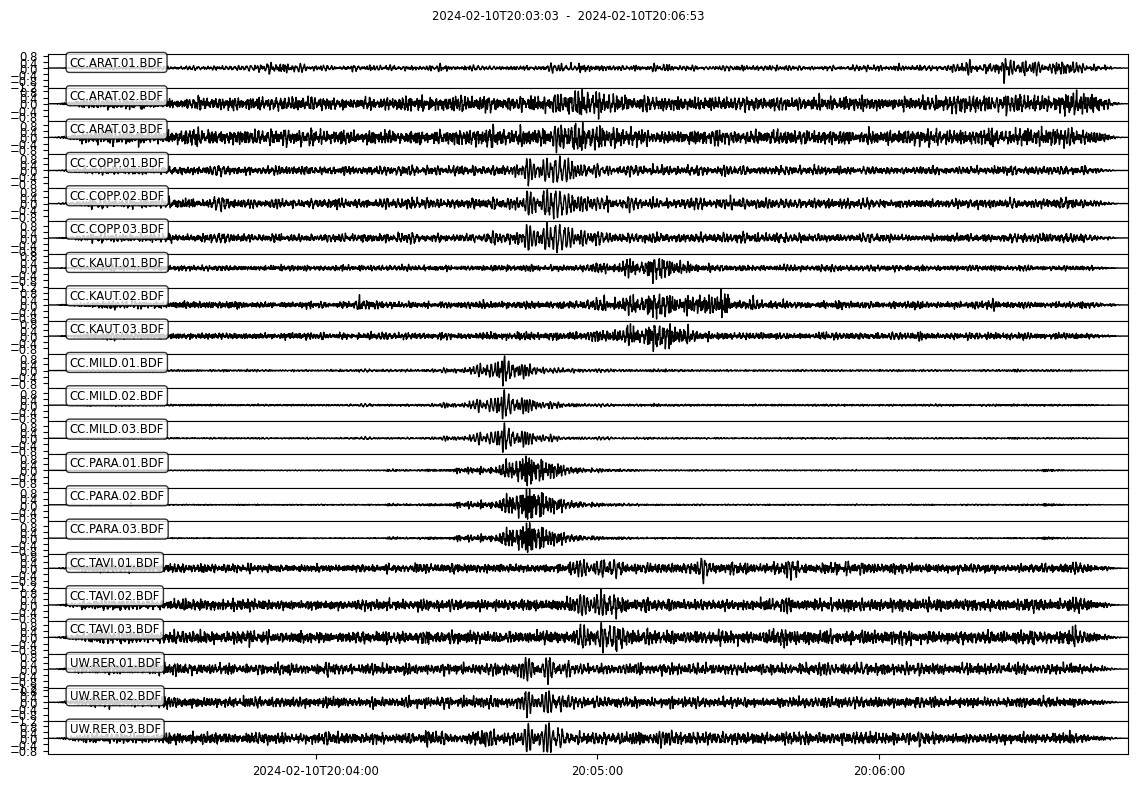

[FK CC_ARAT] OK
[FK CC_COPP] OK
[FK CC_KAUT] OK
[FK CC_MILD] OK
[FK CC_PARA] OK
[FK CC_TAVI] OK
[FK UW_RER] OK
[PLOT_FK CC_ARAT] OK
[PLOT_FK CC_COPP] OK
[PLOT_FK CC_KAUT] OK
[PLOT_FK CC_MILD] OK
[PLOT_FK CC_PARA] OK
[PLOT_FK CC_TAVI] OK
[PLOT_FK UW_RER] OK
[FD CC_ARAT] FAIL
[FD CC_ARAT] stderr tail:
Traceback (most recent call last):
  File "/home/ak287/miniconda3/envs/infrapy_env/bin/infrapy", line 7, in <module>
    sys.exit(main())
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1161, in __call__
    return self.main(*args, **kwargs)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1082, in main
    rv = self.invoke(ctx)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1697, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1

In [52]:
from obspy import UTCDateTime

cutoff = UTCDateTime("2019-01-01T00:00:00")
mt_rainier_cat_2019 = mt_rainier_cat[mt_rainier_cat["starttime"].apply(lambda t: t >= cutoff)]
df = mt_rainier_cat[mt_rainier_cat['eventid'] == 327]

results = []

for i in range(len(df)):
    
    try:
    

        # 1) build stream for event i
        st_all = plot_event_infrasound(df, i, filtered_inv, client, freqmin = 1,  freqmax = 10)

        # 2) get truth (however your catalog stores it)
        truth_lat = float(mt_rainier_cat_2019.iloc[i]["latitude"])   # adjust column names
        truth_lon = float(mt_rainier_cat_2019.iloc[i]["longitude"])

        # 3) run pipeline for that event
        out = run_infrapy_pipeline_for_event(
            st_all=st_all,
            client=client,
            event_id=i,
            truth_lat=truth_lat,
            truth_lon=truth_lon,
            inv_hint=inv,
            OUTROOT="infrapy_runs",

            fk_args=dict(
                freq_min="1",
                freq_max="10",
                window_len="10.0",
                window_step="5.0",
                trace_vel_min="250.0",
                trace_vel_max="700.0",
                trace_vel_step="5.0",
                back_az_step="2.0",
                method="bartlett",
            ),

            fd_args=dict(
                p_value="0.05",
                min_duration="3.0",
                back_az_width="25.0",
                return_thresh=True,
            ),

            assoc_args= None,
            loc_args= None,
        )

        print("DONE:", i, out["ok"], out.get("reason", ""))
        results.append(out)
        
    except:
        pass
        



## QuakeXNet detected events

In [11]:
su_event_catalog = pd.read_csv('../src/surface_events_10_stations_dec_2025.csv')

In [12]:
def plot_event_infrasound(mt_rainier_cat, event_idx, inv, client,
                          pad_before= 100, pad_after= 300,
                          freqmin=0.5, freqmax=10.0,
                          max_traces= 2e+10):
    """
    mt_rainier_cat: must let you access start/end as UTCDateTime or ISO string
    event_idx: index of event row
    inv: station inventory returned by get_stations (level="channel")
    """
    # ---- get start/end from your catalog row ----
    row = mt_rainier_cat.iloc[event_idx]  # if it's a pandas DF
    t0 = row["rounded_start"]
    t1 = row["rounded_start"]

    
    dt = datetime.fromisoformat(t0).replace(tzinfo=timezone.utc)
    t0 = UTCDateTime(dt)
    
    dt = datetime.fromisoformat(t1).replace(tzinfo=timezone.utc)
    t1 = UTCDateTime(dt)
    
    # Make sure UTCDateTime
    if not isinstance(t0, UTCDateTime):
        t0 = UTCDateTime(t0)
    if not isinstance(t1, UTCDateTime):
        t1 = UTCDateTime(t1)

    tstart = t0 - pad_before
    tend   = t0 + pad_after

    # ---- gather infrasound traces ----
    st_all = Stream()
    picked = 0

    for net in inv:
        for sta in net:
            for cha in sta:
                code = cha.code
                if len(code) == 3 and code[1] != "D":
                    continue
                loc = cha.location_code or ""

                try:
                    st = client.get_waveforms(
                        network=net.code, station=sta.code, location=loc, channel=code,
                        starttime=tstart, endtime=tend, attach_response=False
                    )
                except Exception:
                    continue

                if len(st) == 0:
                    continue

                st = preprocess_infrasound(st, inv=None, freqmin=freqmin, freqmax=freqmax)
                st_all += st
                picked += len(st)
                if picked >= max_traces:
                    break
            if picked >= max_traces:
                break
        if picked >= max_traces:
            break

    if len(st_all) == 0:
        print(f"No infrasound data found for event {event_idx} in window {tstart} - {tend}")
        return None

    # ---- plot ----
    # ObsPy's built-in plotting is quick; it makes a stacked plot per trace
    # Normalize each trace individually
    
    
    

    st_all = merge_overlaps_by_id(st_all, fill="interpolate")
    st_all = drop_exact_clones(st_all)
    st_all = drop_low_snr_traces(st_all, verbose = False)
    
    
    st_all, array_snr = filter_arrays_by_envelope_snr(
    st_all,
    snr_threshold= 6.0,
    agg="mean",
    smooth_sec=0.5,
    baseline="median",
    quantile_peak=0.99)
    
    st_norm = normalize_stream_by_max(st_all)

    st_norm.plot(
        type="normal",
        size=(1200, 800),
        title=f"Event {event_idx}: {t0} to {t1} "
              f"(normalized, bandpass {freqmin}-{freqmax} Hz)"
    )

    return st_all

In [13]:
# case wise testing for the research presentation
#su_event_catalog = su_event_catalog[su_event_catalog['cluster_id'] == 13469]

Kept 1 arrays
Dropped 20 arrays


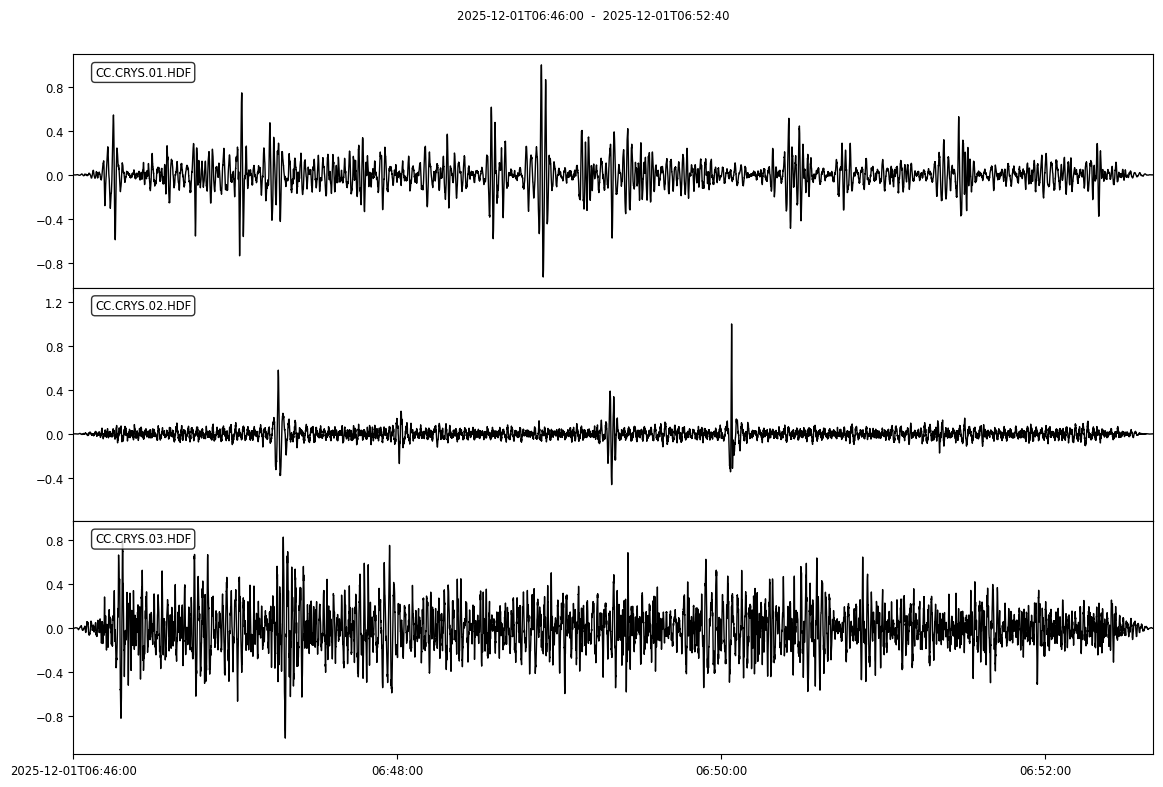

[FK CC_CRYS] OK
[FD CC_CRYS] FAIL
[FD CC_CRYS] stderr tail:
Traceback (most recent call last):
  File "/home/ak287/miniconda3/envs/infrapy_env/bin/infrapy", line 7, in <module>
    sys.exit(main())
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1161, in __call__
    return self.main(*args, **kwargs)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1082, in main
    rv = self.invoke(ctx)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1697, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1443, in invoke
    return ctx.invoke(self.callback, **ctx.params)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 788, in invoke
    return __callback(*args, **kwargs)
  File "/home/ak287/infr

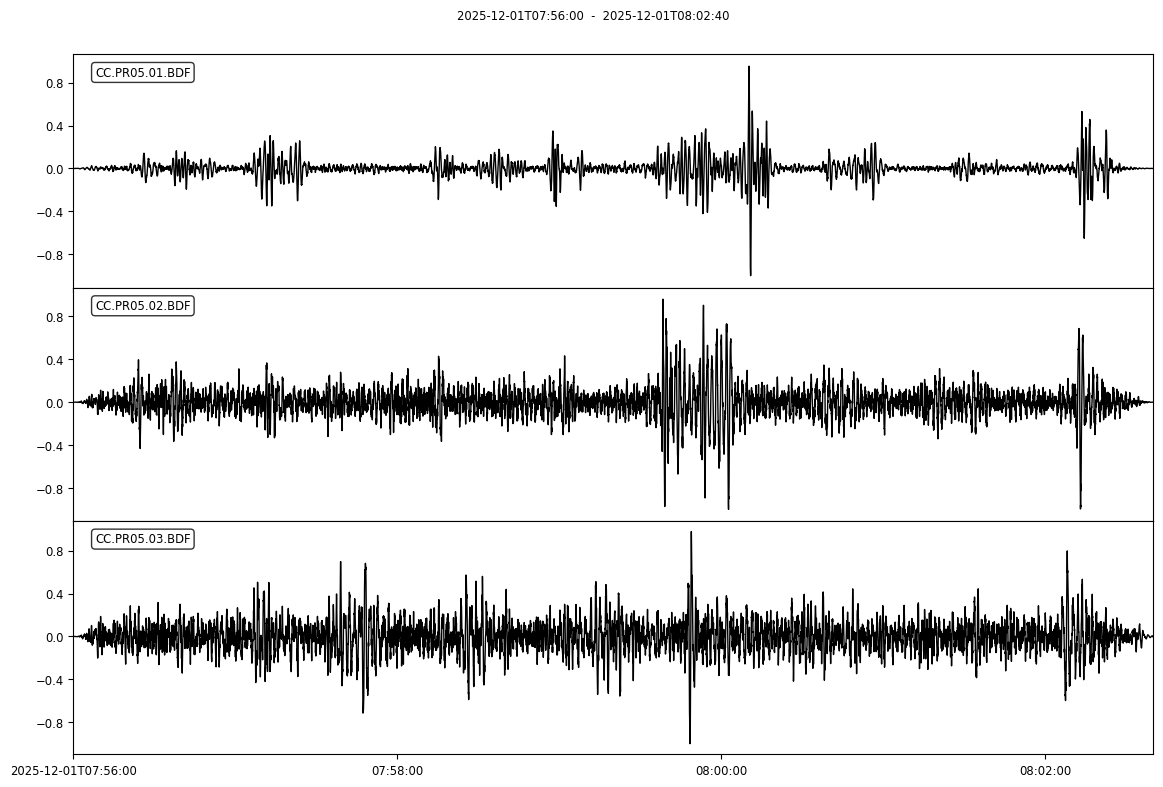

[FK CC_PR05] OK
[FD CC_PR05] FAIL
[FD CC_PR05] stderr tail:
Traceback (most recent call last):
  File "/home/ak287/miniconda3/envs/infrapy_env/bin/infrapy", line 7, in <module>
    sys.exit(main())
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1161, in __call__
    return self.main(*args, **kwargs)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1082, in main
    rv = self.invoke(ctx)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1697, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1443, in invoke
    return ctx.invoke(self.callback, **ctx.params)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 788, in invoke
    return __callback(*args, **kwargs)
  File "/home/ak287/infr

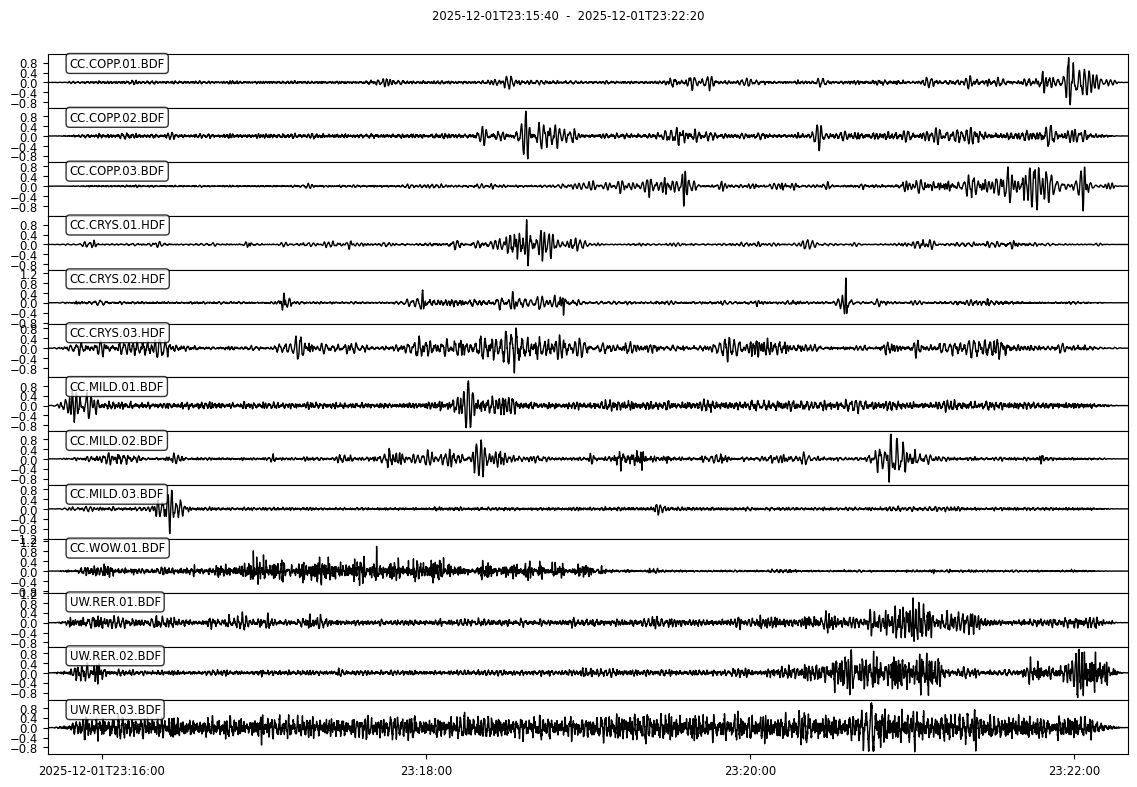

[FK CC_COPP] OK
[FK CC_CRYS] OK
[FK CC_MILD] OK
[FK CC_WOW] OK
[FK UW_RER] OK
[FD CC_COPP] OK
[FD CC_CRYS] OK
[FD CC_MILD] OK
[FD CC_WOW] FAIL
[FD CC_WOW] stderr tail:
    return __callback(*args, **kwargs)
  File "/home/ak287/infrapy/infrapy/cli/cli_detection.py", line 413, in run_fd
    dets, thresh_vals = fkd.run_fd(beam_times, beam_peaks, window_len, TB_prod, channel_cnt, p_value, min_seq, back_az_width, fixed_thresh, thresh_ceil, True, merge_dets)
  File "/home/ak287/infrapy/infrapy/detection/beamforming_new.py", line 1043, in run_fd
    thresh = calc_det_thresh(fstat_vals[win_mask], det_p_val, TB_prod, channel_cnt, fstat_ref_peak=fstat_ref_peak)
  File "/home/ak287/infrapy/infrapy/detection/beamforming_new.py", line 861, in calc_det_thresh
    kde = stats.gaussian_kde(fstat_vals)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/scipy/stats/_kde.py", line 226, in __init__
    self.set_bandwidth(bw_method=bw_method)
  File "/home/ak287/miniconda3/envs/inf

/tmp/ipykernel_2231996/2771227421.py:524: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/tmp/ipykernel_2231996/2771227421.py:533: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/tmp/ipykernel_2231996/2771227421.py:544: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



/tmp/ipykernel_2231996/2771227421.py:577: DeprecationWarning:

*densitymapbox* is deprecated! Use *densitymap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/tmp/ipykernel_2231996/2771227421.py:584: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/tmp/ipykernel_2231996/2771227421.py:592: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/tmp/ipykernel_2231996/2771227421.py:600: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



DONE: 3 True 
Kept 7 arrays
Dropped 14 arrays


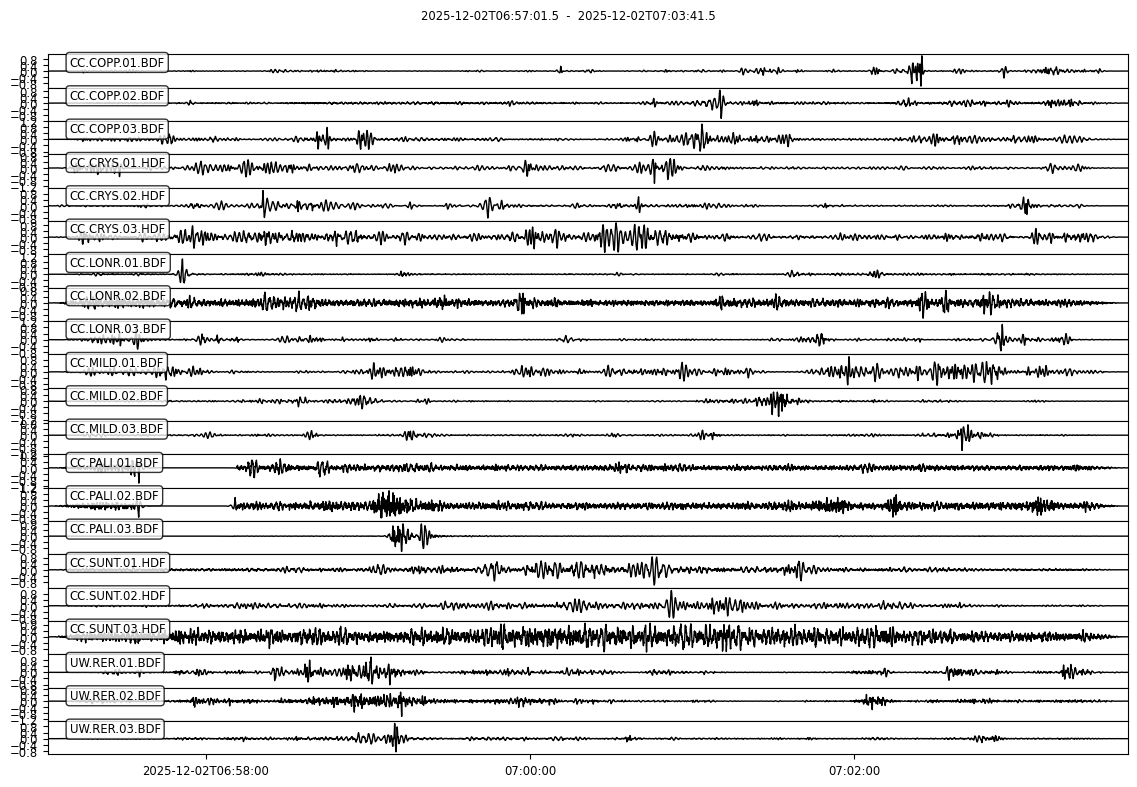

[FK CC_COPP] OK
[FK CC_CRYS] OK
[FK CC_LONR] OK
[FK CC_MILD] OK
[FK CC_PALI] OK
[FK CC_SUNT] OK
[FK UW_RER] OK
[FD CC_COPP] FAIL
[FD CC_COPP] stderr tail:
Traceback (most recent call last):
  File "/home/ak287/miniconda3/envs/infrapy_env/bin/infrapy", line 7, in <module>
    sys.exit(main())
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1161, in __call__
    return self.main(*args, **kwargs)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1082, in main
    rv = self.invoke(ctx)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1697, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1443, in invoke
    return ctx.invoke(self.callback, **ctx.params)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/clic

/tmp/ipykernel_2231996/2771227421.py:524: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/tmp/ipykernel_2231996/2771227421.py:533: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/tmp/ipykernel_2231996/2771227421.py:544: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



/tmp/ipykernel_2231996/2771227421.py:577: DeprecationWarning:

*densitymapbox* is deprecated! Use *densitymap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/tmp/ipykernel_2231996/2771227421.py:584: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/tmp/ipykernel_2231996/2771227421.py:592: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/tmp/ipykernel_2231996/2771227421.py:600: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



DONE: 4 True 
Kept 7 arrays
Dropped 13 arrays


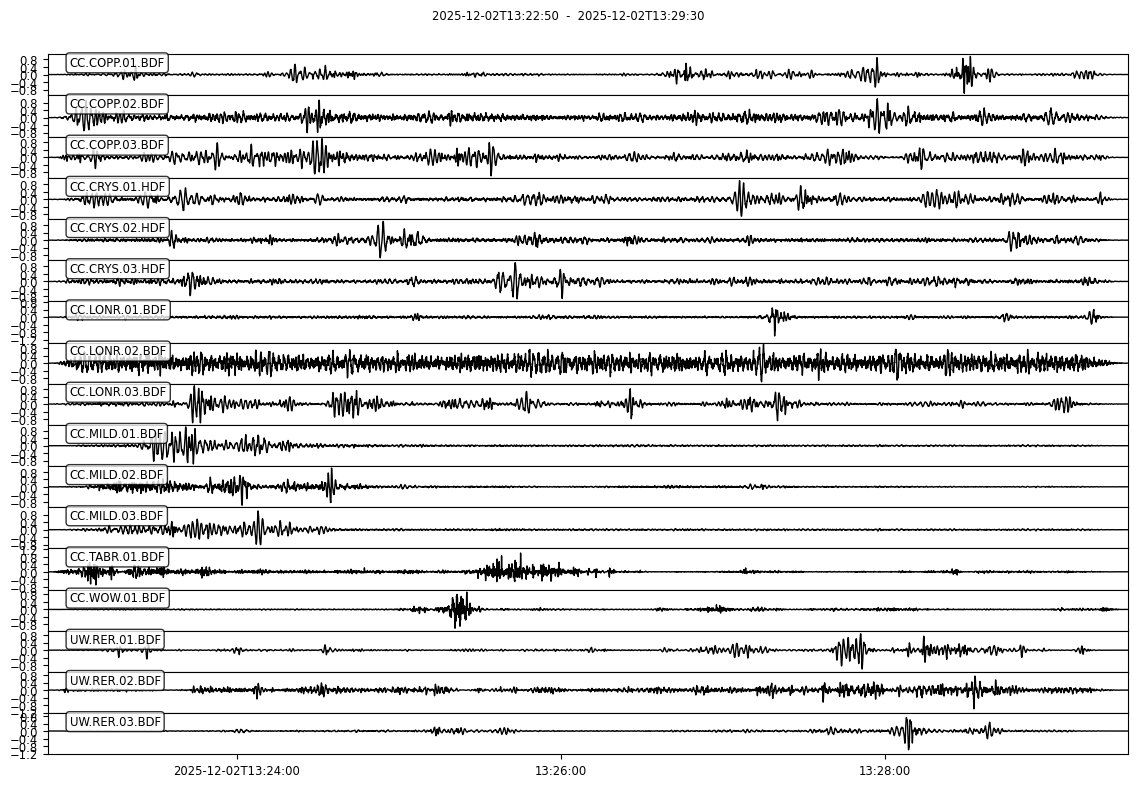

[FK CC_COPP] OK
[FK CC_CRYS] OK
[FK CC_LONR] OK
[FK CC_MILD] OK
[FK CC_TABR] OK
[FK CC_WOW] OK
[FK UW_RER] OK
[FD CC_COPP] OK
[FD CC_CRYS] FAIL
[FD CC_CRYS] stderr tail:
Traceback (most recent call last):
  File "/home/ak287/miniconda3/envs/infrapy_env/bin/infrapy", line 7, in <module>
    sys.exit(main())
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1161, in __call__
    return self.main(*args, **kwargs)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1082, in main
    rv = self.invoke(ctx)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1697, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1443, in invoke
    return ctx.invoke(self.callback, **ctx.params)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/sit

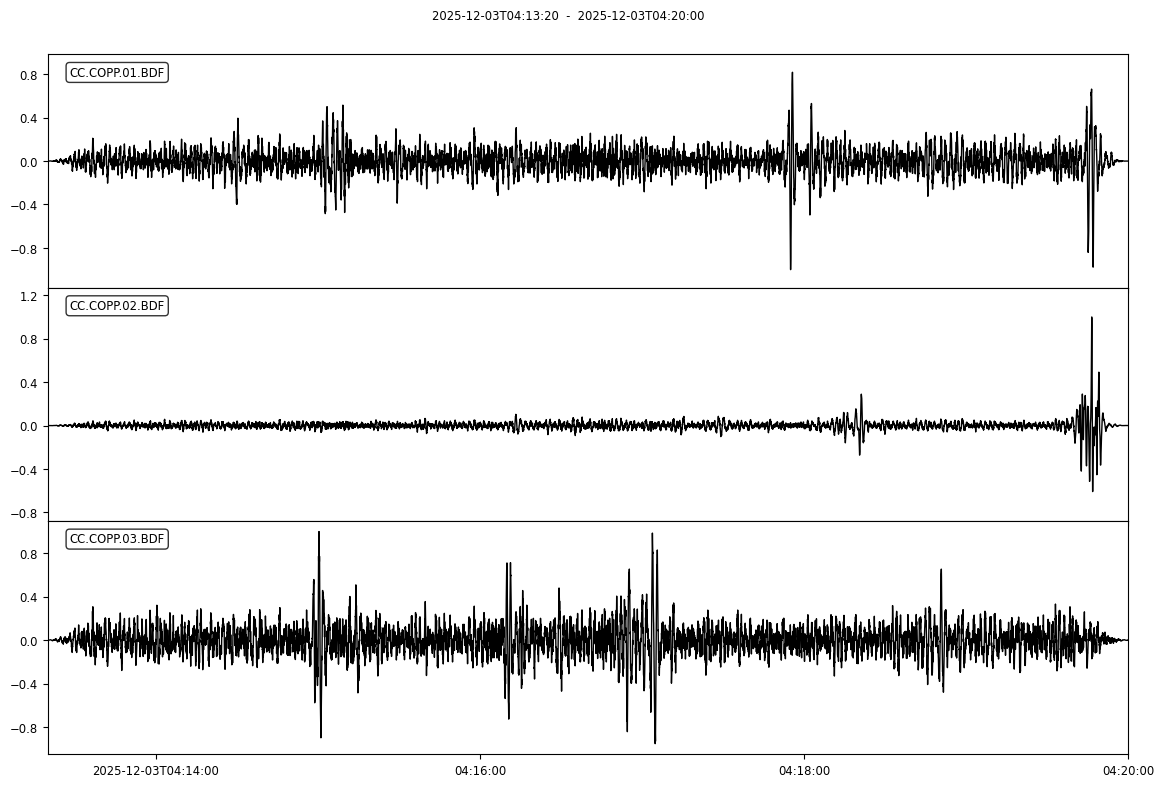

[FK CC_COPP] OK
[FD CC_COPP] OK
[ASSOC] FAIL
[ASSOC] stderr tail:
Traceback (most recent call last):
  File "/home/ak287/miniconda3/envs/infrapy_env/bin/infrapy", line 7, in <module>
    sys.exit(main())
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1161, in __call__
    return self.main(*args, **kwargs)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1082, in main
    rv = self.invoke(ctx)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1697, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1443, in invoke
    return ctx.invoke(self.callback, **ctx.params)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 788, in invoke
    return __callback(*args, **kwargs)
  File "/home/ak28

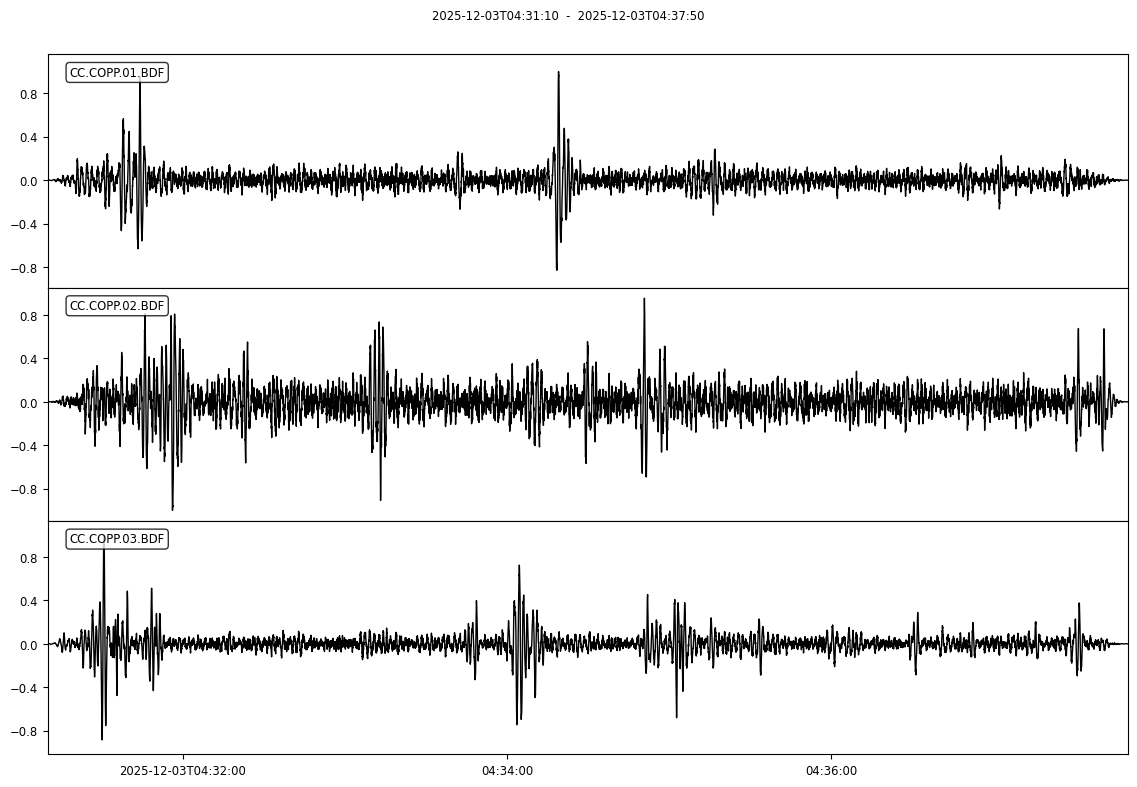

[FK CC_COPP] OK
[FD CC_COPP] OK
[ASSOC] FAIL
[ASSOC] stderr tail:
Traceback (most recent call last):
  File "/home/ak287/miniconda3/envs/infrapy_env/bin/infrapy", line 7, in <module>
    sys.exit(main())
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1161, in __call__
    return self.main(*args, **kwargs)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1082, in main
    rv = self.invoke(ctx)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1697, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1443, in invoke
    return ctx.invoke(self.callback, **ctx.params)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 788, in invoke
    return __callback(*args, **kwargs)
  File "/home/ak28

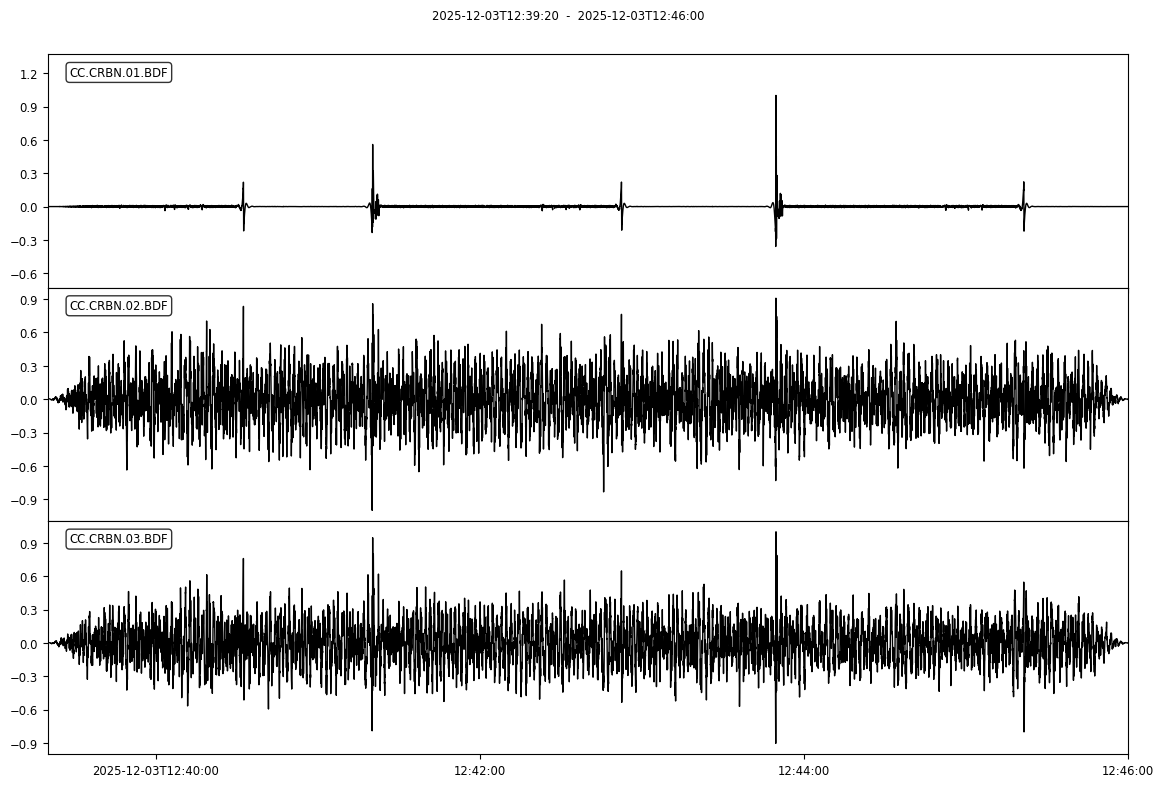

[FK CC_CRBN] OK
[FD CC_CRBN] FAIL
[FD CC_CRBN] stderr tail:
Traceback (most recent call last):
  File "/home/ak287/miniconda3/envs/infrapy_env/bin/infrapy", line 7, in <module>
    sys.exit(main())
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1161, in __call__
    return self.main(*args, **kwargs)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1082, in main
    rv = self.invoke(ctx)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1697, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1443, in invoke
    return ctx.invoke(self.callback, **ctx.params)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 788, in invoke
    return __callback(*args, **kwargs)
  File "/home/ak287/infr

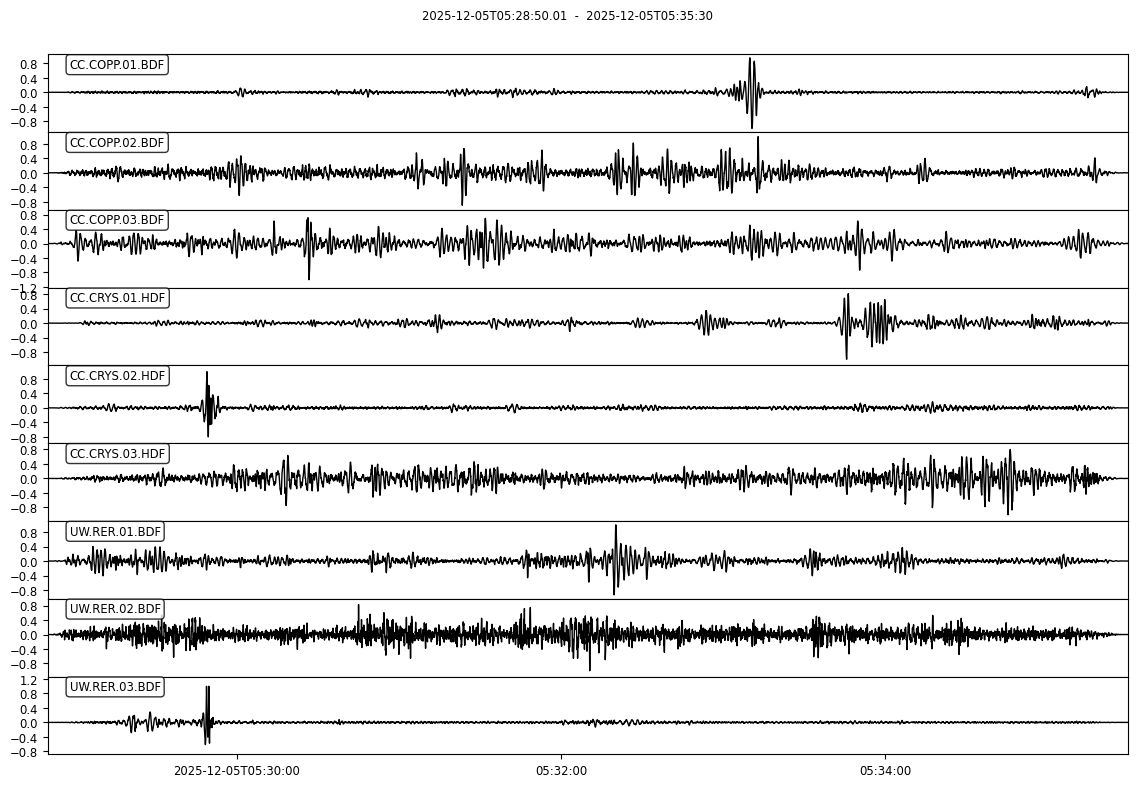

[FK CC_COPP] OK
[FK CC_CRYS] OK
[FK UW_RER] OK
[FD CC_COPP] FAIL
[FD CC_COPP] stderr tail:
Traceback (most recent call last):
  File "/home/ak287/miniconda3/envs/infrapy_env/bin/infrapy", line 7, in <module>
    sys.exit(main())
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1161, in __call__
    return self.main(*args, **kwargs)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1082, in main
    rv = self.invoke(ctx)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1697, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1443, in invoke
    return ctx.invoke(self.callback, **ctx.params)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 788, in invoke
    return __callback(*args, **k

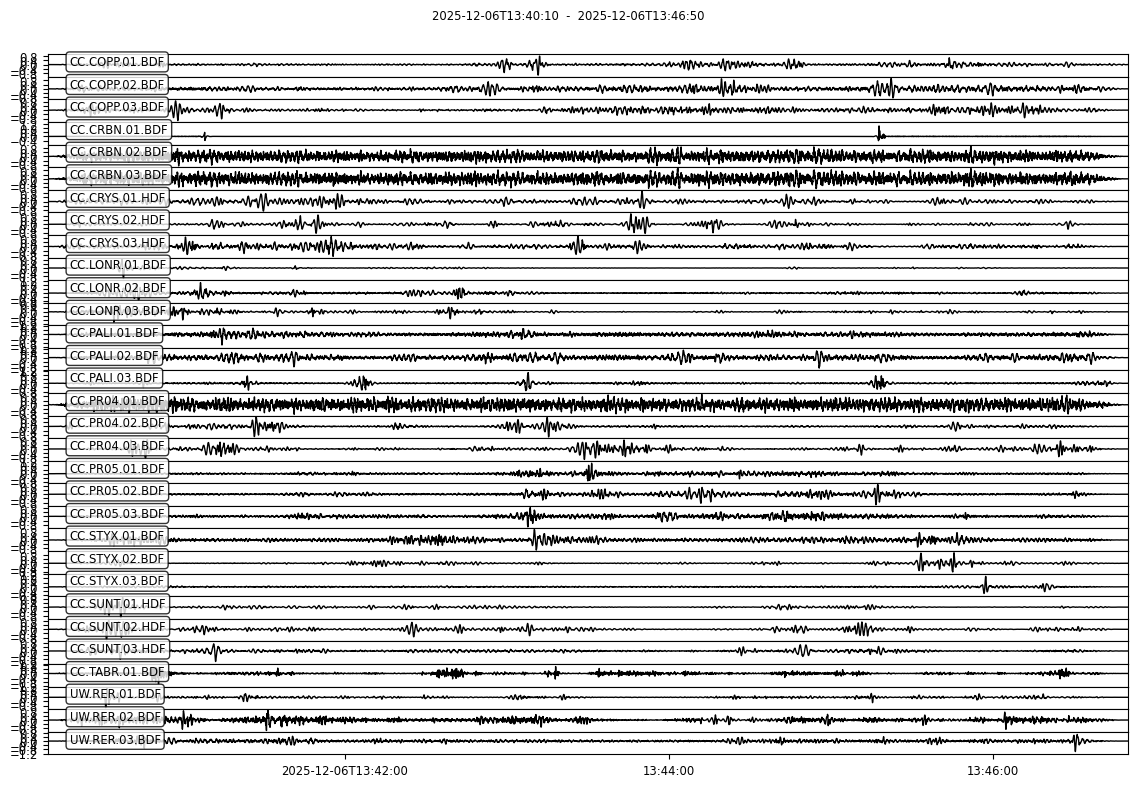

[FK CC_COPP] OK
[FK CC_CRBN] OK
[FK CC_CRYS] OK
[FK CC_LONR] OK
[FK CC_PALI] OK
[FK CC_PR04] OK
[FK CC_PR05] OK
[FK CC_STYX] OK
[FK CC_SUNT] OK
[FK CC_TABR] OK
[FK UW_RER] OK
[FD CC_COPP] FAIL
[FD CC_COPP] stderr tail:
Traceback (most recent call last):
  File "/home/ak287/miniconda3/envs/infrapy_env/bin/infrapy", line 7, in <module>
    sys.exit(main())
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1161, in __call__
    return self.main(*args, **kwargs)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1082, in main
    rv = self.invoke(ctx)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1697, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1443, in invoke
    return ctx.invoke(self.callback, **ctx.params)
  File "/home/ak

[FD CC_TABR] FAIL
[FD CC_TABR] stderr tail:
    return __callback(*args, **kwargs)
  File "/home/ak287/infrapy/infrapy/cli/cli_detection.py", line 413, in run_fd
    dets, thresh_vals = fkd.run_fd(beam_times, beam_peaks, window_len, TB_prod, channel_cnt, p_value, min_seq, back_az_width, fixed_thresh, thresh_ceil, True, merge_dets)
  File "/home/ak287/infrapy/infrapy/detection/beamforming_new.py", line 1043, in run_fd
    thresh = calc_det_thresh(fstat_vals[win_mask], det_p_val, TB_prod, channel_cnt, fstat_ref_peak=fstat_ref_peak)
  File "/home/ak287/infrapy/infrapy/detection/beamforming_new.py", line 861, in calc_det_thresh
    kde = stats.gaussian_kde(fstat_vals)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/scipy/stats/_kde.py", line 226, in __init__
    self.set_bandwidth(bw_method=bw_method)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/scipy/stats/_kde.py", line 574, in set_bandwidth
    self._compute_covariance()
  File 

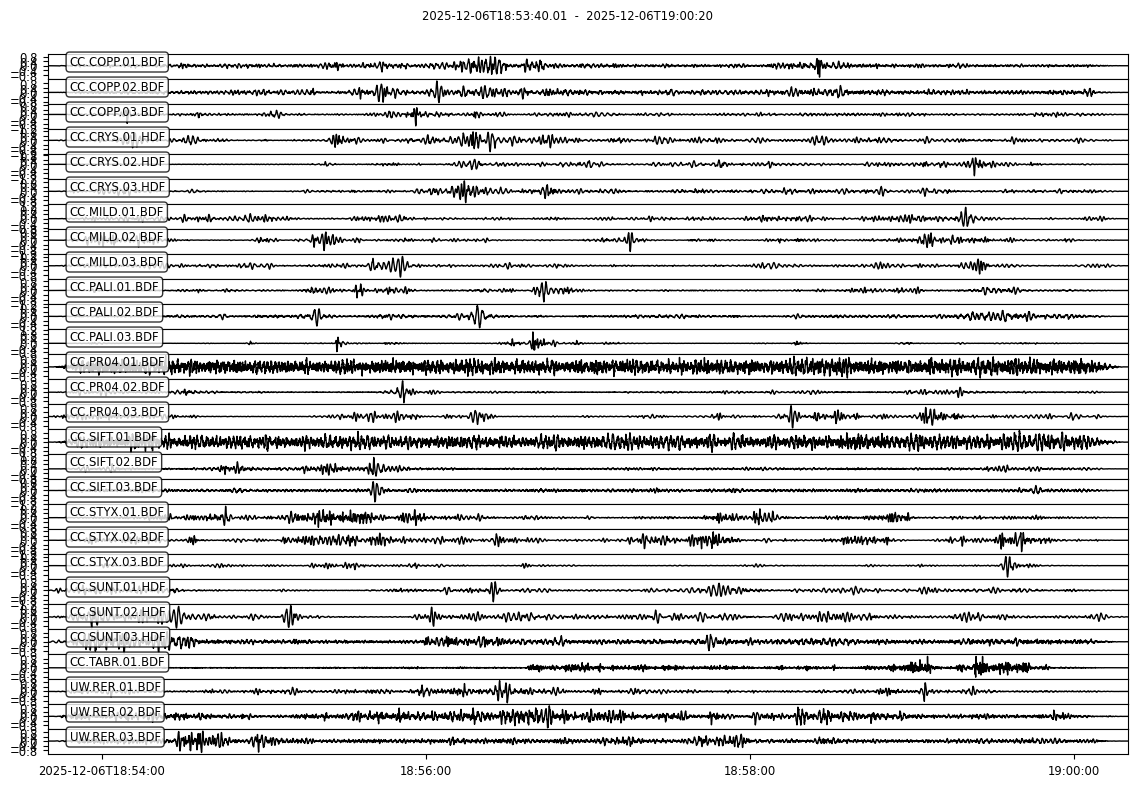

[FK CC_COPP] OK
[FK CC_CRYS] OK
[FK CC_MILD] OK
[FK CC_PALI] OK
[FK CC_PR04] OK
[FK CC_SIFT] OK
[FK CC_STYX] OK
[FK CC_SUNT] OK
[FK CC_TABR] OK
[FK UW_RER] OK
[FD CC_COPP] FAIL
[FD CC_COPP] stderr tail:
Traceback (most recent call last):
  File "/home/ak287/miniconda3/envs/infrapy_env/bin/infrapy", line 7, in <module>
    sys.exit(main())
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1161, in __call__
    return self.main(*args, **kwargs)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1082, in main
    rv = self.invoke(ctx)
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1697, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
  File "/home/ak287/miniconda3/envs/infrapy_env/lib/python3.9/site-packages/click/core.py", line 1443, in invoke
    return ctx.invoke(self.callback, **ctx.params)
  File "/home/ak287/miniconda3/e

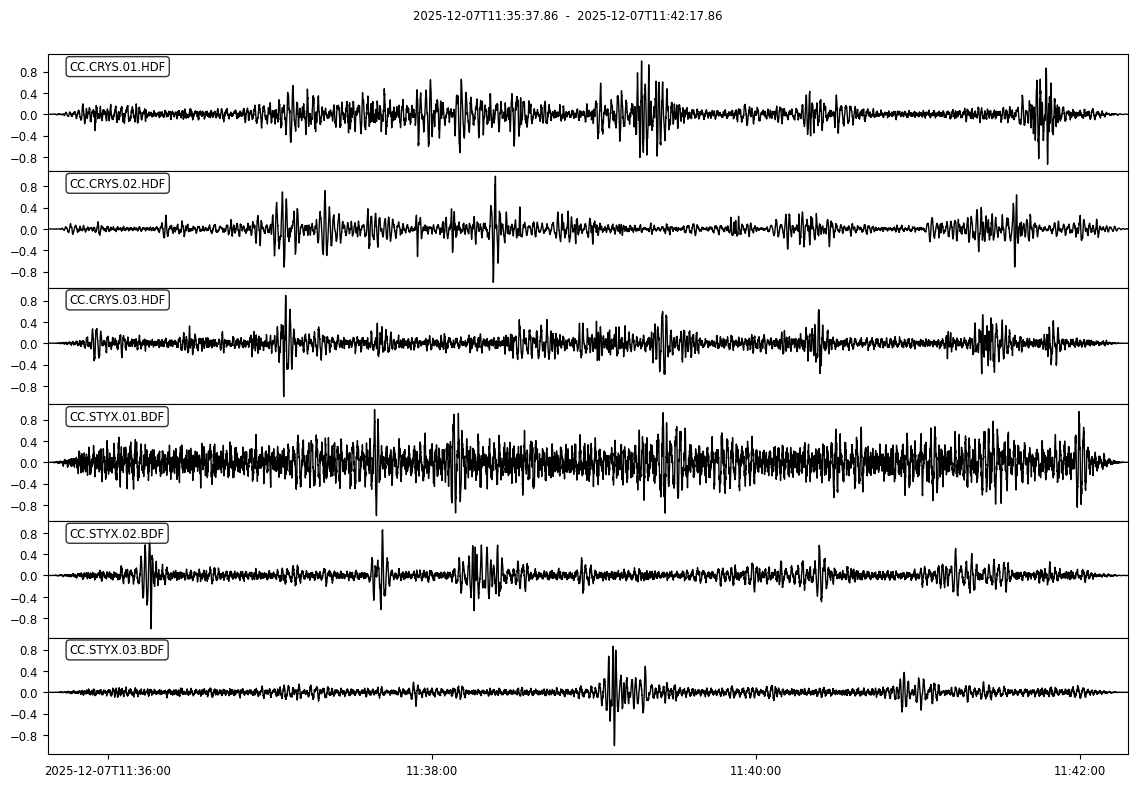

[FK CC_CRYS] OK
[FK CC_STYX] OK
[FD CC_CRYS] OK


In [ ]:
from obspy import UTCDateTime
from datetime import datetime, timezone




results = []

for i in range(len(su_event_catalog)):
    
    try:
    

        # 1) build stream for event i
        st_all = plot_event_infrasound(su_event_catalog, i, inv, client, )

        # 2) get truth (however your catalog stores it)
        truth_lat = float(su_event_catalog.iloc[i]["enveloc_latitude"])   # adjust column names
        truth_lon = float(su_event_catalog.iloc[i]["enveloc_longitude"])

        # 3) run pipeline for that event
        out = run_infrapy_pipeline_for_event(
            st_all=st_all,
            client=client,
            event_id=i,
            truth_lat=truth_lat,
            truth_lon=truth_lon,
            inv_hint=inv,
            OUTROOT="infrapy_runs",

            fk_args=dict(
                freq_min="1.0",
                freq_max="10.0",
                window_len="6.0",
                window_step="2.0",
                trace_vel_min="250.0",
                trace_vel_max="700.0",
                trace_vel_step="5.0",
                back_az_step="2.0",
                method="bartlett",
            ),

            fd_args=dict(
                p_value="0.05",
                min_duration="3.0",
                back_az_width="25.0",
                return_thresh=True,
            ),

            assoc_args= None,
            loc_args= None,
        )

        print("DONE:", i, out["ok"], out.get("reason", ""))
        results.append(out)
        
    except:
        pass
        



In [74]:
su_event_catalog['rounded_start'].v

AttributeError: 'Series' object has no attribute 'v'

In [35]:
su_event_catalog

,Unnamed: 0.1,Unnamed: 0,cluster_id,rounded_start,num_stations,stations,all_classes,most_common_class,mean_auc,mean_max,mean_prob,enveloc_latitude,enveloc_longitude
0,0,105,432,2025-12-01 07:57:40+00:00,11,"['ARAT', 'COPP', 'LO2', 'MILD', 'OBSR', 'PANH'...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,7.456046,0.793113,0.479240,46.857925,-121.742546
1,1,345,1278,2025-12-01 23:17:20+00:00,19,"['ARAT', 'COPP', 'FMW', 'LO2', 'LON', 'LONR', ...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,6.819350,0.815300,0.502831,46.868918,-121.734406
2,2,547,2116,2025-12-02 13:24:30+00:00,12,"['BHW', 'COPP', 'FMW', 'GPW', 'JCW', 'LON', 'M...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,15.450455,0.798916,0.514053,46.812366,-121.722262
3,3,844,3482,2025-12-03 12:41:00+00:00,12,"['ARAT', 'COPP', 'FMW', 'LO2', 'LON', 'MILD', ...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,5.597377,0.761653,0.468448,46.818338,-121.714892
4,4,1103,4572,2025-12-04 06:57:00+00:00,22,"['ARAT', 'CARB', 'COPP', 'CRBN', 'FMW', 'GNOB'...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,7.624186,0.763904,0.429611,NaN,NaN
5,5,1870,8262,2025-12-06 18:55:20.002857+00:00,16,"['ARAT', 'COPP', 'CRYS', 'FMW', 'GNOB', 'LON',...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,7.871611,0.877268,0.553660,46.854614,-121.759687
6,6,2232,10611,2025-12-08 09:57:20+00:00,11,"['ARAT', 'COPP', 'GNOB', 'LON', 'LTY', 'MILD',...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,8.004866,0.885728,0.554033,46.847490,-121.734693
7,7,2650,13213,2025-12-10 05:12:00+00:00,14,"['COPP', 'CRYS', 'GPW', 'LON', 'LONR', 'MILD',...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,7.516970,0.751089,0.442377,46.868882,-121.770200
8,8,2694,13469,2025-12-10 09:26:02.880000+00:00,12,"['COPP', 'CRYS', 'LO2', 'LONR', 'MILD', 'OBSR'...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,7.514473,0.803965,0.495088,NaN,NaN
9,9,2891,15124,2025-12-11 12:42:02.300000+00:00,12,"['BHW', 'COPP', 'GNOB', 'LONR', 'MILD', 'OBSR'...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,9.901246,0.925788,0.610464,NaN,NaN
